1. Importing  the Library

In [91]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

In [92]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "mit-bih-arrhythmia-database-1.0.0"
)

METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "eda"
)

METADATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [93]:
print("Project root:")
print(PROJECT_ROOT)

print("\nContents:")
for item in PROJECT_ROOT.iterdir():
    print(item.name)

Project root:
/home/raju/thesis_project

Contents:
logs
.gitignore
notebooks
.git
results
experiments
src
data
README.md
requirements.txt
configs
.venv


In [94]:
print(RAW_DIR)
print(RAW_DIR.exists())

/home/raju/thesis_project/data/raw/mit-bih-arrhythmia-database-1.0.0
True


In [95]:
from src.dataset import get_record_ids, load_record

records = get_record_ids(RAW_DIR)

print("Number of records:", len(records))
print(records)

Number of records: 48
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [96]:
record_id = records[0]

record = wfdb.rdrecord(str(RAW_DIR / record_id))

print("Record:", record_id)
print("Sampling frequency:", record.fs)
print("Signal shape:", record.p_signal.shape)
print("Channels:", record.sig_name)
print("Units:", record.units)
print("ADC gain:", record.adc_gain)
print("Baseline:", record.baseline)

Record: 100
Sampling frequency: 360
Signal shape: (650000, 2)
Channels: ['MLII', 'V5']
Units: ['mV', 'mV']
ADC gain: [200.0, 200.0]
Baseline: [1024, 1024]


In [97]:
print(record.__dict__.keys())

dict_keys(['record_name', 'n_sig', 'fs', 'counter_freq', 'base_counter', 'sig_len', 'base_time', 'base_date', 'comments', 'sig_name', 'p_signal', 'd_signal', 'e_p_signal', 'e_d_signal', 'file_name', 'fmt', 'samps_per_frame', 'skew', 'byte_offset', 'adc_gain', 'baseline', 'units', 'adc_res', 'adc_zero', 'init_value', 'checksum', 'block_size'])


In [98]:
print(record.comments)

['69 M 1085 1629 x1', 'Aldomet, Inderal']


In [99]:
signal = record.p_signal

print(
    "Number of samples:",
    signal.shape[0]
)

print(
    "Number of channels:",
    signal.shape[1]
)

print(
    "Duration:",
    signal.shape[0] / record.fs,
    "seconds"
)

print(
    "Duration:",
    signal.shape[0] / record.fs / 60,
    "minutes"
)

print(
    "Minimum amplitude:",
    np.min(signal)
)

print(
    "Maximum amplitude:",
    np.max(signal)
)

print(
    "Mean amplitude:",
    np.mean(signal)
)

print(
    "Standard deviation:",
    np.std(signal)
)

Number of samples: 650000
Number of channels: 2
Duration: 1805.5555555555557 seconds
Duration: 30.092592592592595 minutes
Minimum amplitude: -2.715
Maximum amplitude: 1.435
Mean amplitude: -0.24866670384615383
Standard deviation: 0.18157117166295547


In [100]:
print(
    "NaN values:",
    np.isnan(signal).sum()
)

print(
    "Infinite values:",
    np.isinf(signal).sum()
)

NaN values: 0
Infinite values: 0


In [101]:
metadata = []

for record_id in records:
    record = wfdb.rdrecord(str(RAW_DIR / record_id))
    metadata.append({
        "record_id": record_id,
        "sampling_frequency": record.fs,
        "num_samples": record.sig_len,
        "duration_seconds": record.sig_len / record.fs,
        "duration_minutes": record.sig_len / record.fs / 60,
        "num_channels": record.n_sig,
        "channel_names": ",".join(record.sig_name),

        "min_amplitude": np.min(record.p_signal),
        "max_amplitude": np.max(record.p_signal),
        "mean_amplitude": np.mean(record.p_signal),
        "std_amplitude": np.std(record.p_signal),

        "num_nan_values": np.isnan(record.p_signal).sum(),
        "num_inf_values": np.isinf(record.p_signal).sum(),
    })

    record_metadata = pd.DataFrame(metadata)
    record_metadata.to_csv(METADATA_DIR / "record_metadata.csv", index=False)

In [102]:
record_metadata.head()

,record_id,sampling_frequency,num_samples,duration_seconds,duration_minutes,num_channels,channel_names,min_amplitude,max_amplitude,mean_amplitude,std_amplitude,num_nan_values,num_inf_values
0,100,360,650000,1805.555556,30.092593,2,"MLII,V5",-2.715,1.435,-0.248667,0.181571,0,0
1,101,360,650000,1805.555556,30.092593,2,"MLII,V1",-3.175,2.420,-0.181168,0.214342,0,0
2,102,360,650000,1805.555556,30.092593,2,"V5,V2",-3.370,2.535,-0.116636,0.829847,0,0
3,103,360,650000,1805.555556,30.092593,2,"MLII,V2",-5.120,5.115,-0.092207,0.554285,0,0
4,104,360,650000,1805.555556,30.092593,2,"V5,V2",-1.935,1.975,-0.076740,0.271685,0,0


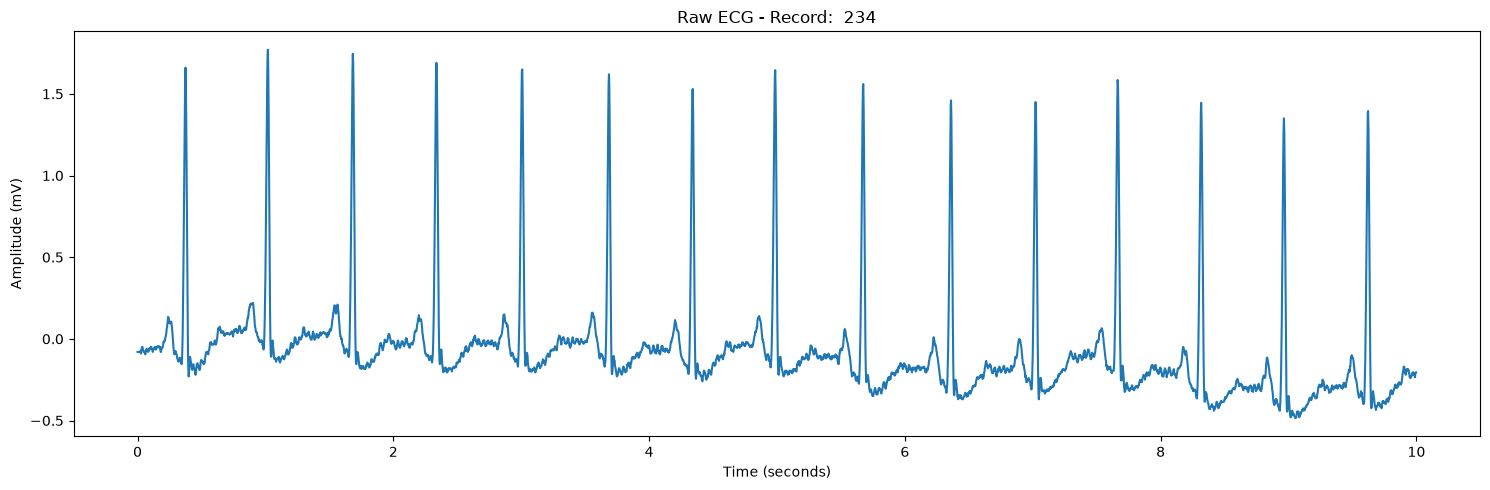

In [103]:

record = wfdb.rdrecord(str(RAW_DIR / record_id))

signal = record.p_signal[:,0]

seconds = np.arange(len(signal)) /record.fs

plt.figure(figsize=(15, 5))
plt.plot(seconds[:3600], signal[:3600])
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Raw ECG - Record:  {record_id}")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / f"raw_ecg_{record_id}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_17406/1652175159.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(15, 5))


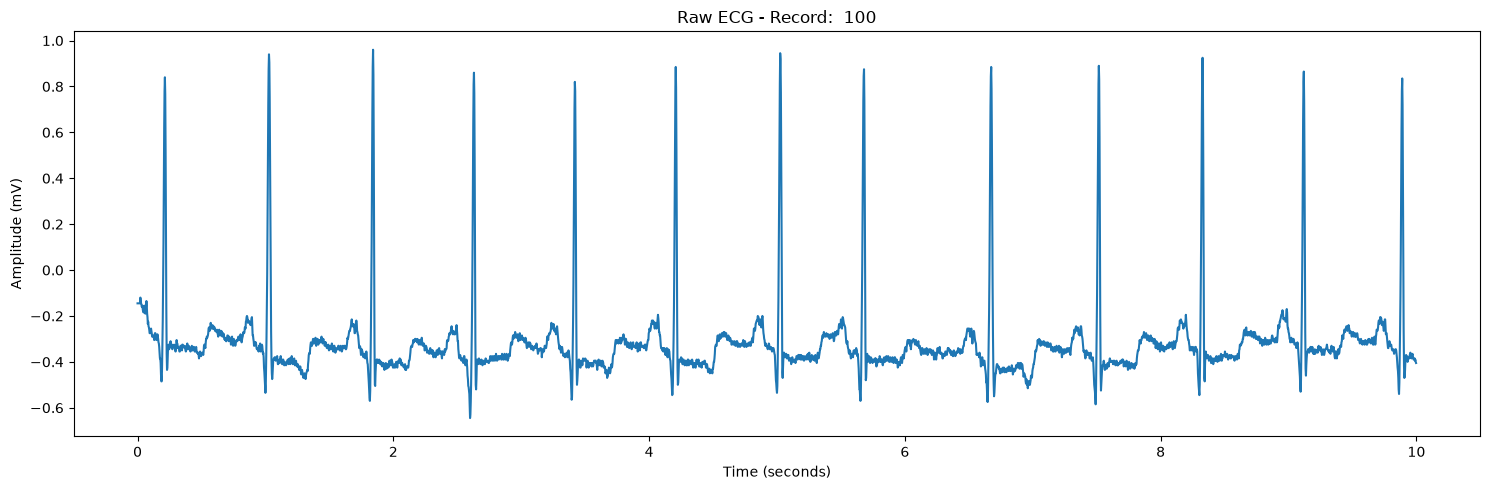

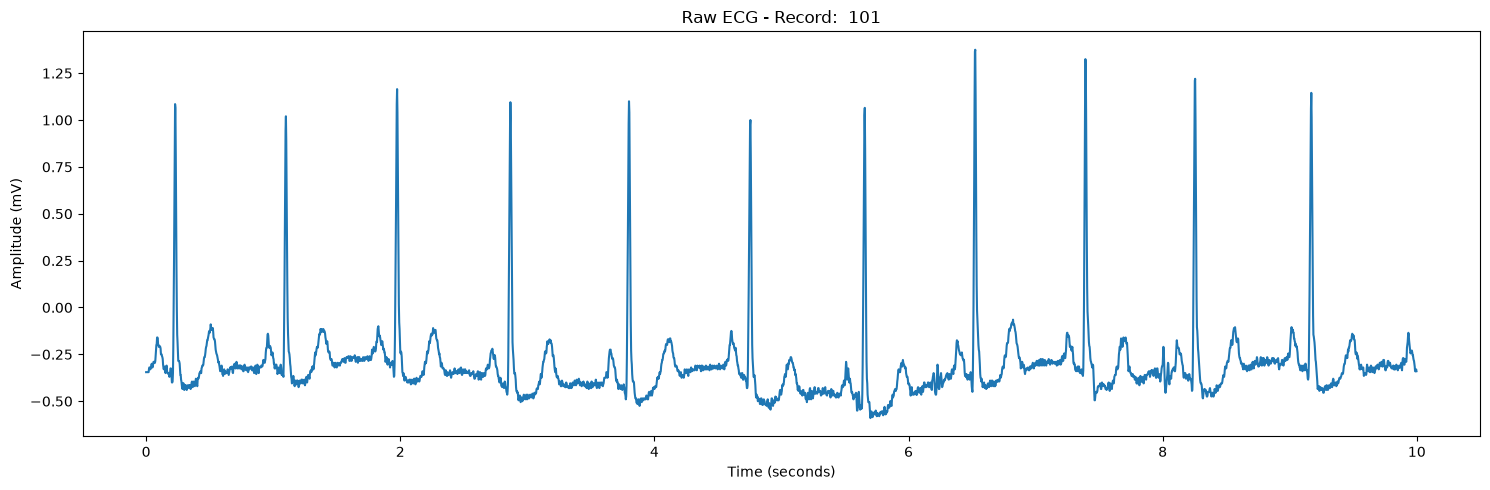

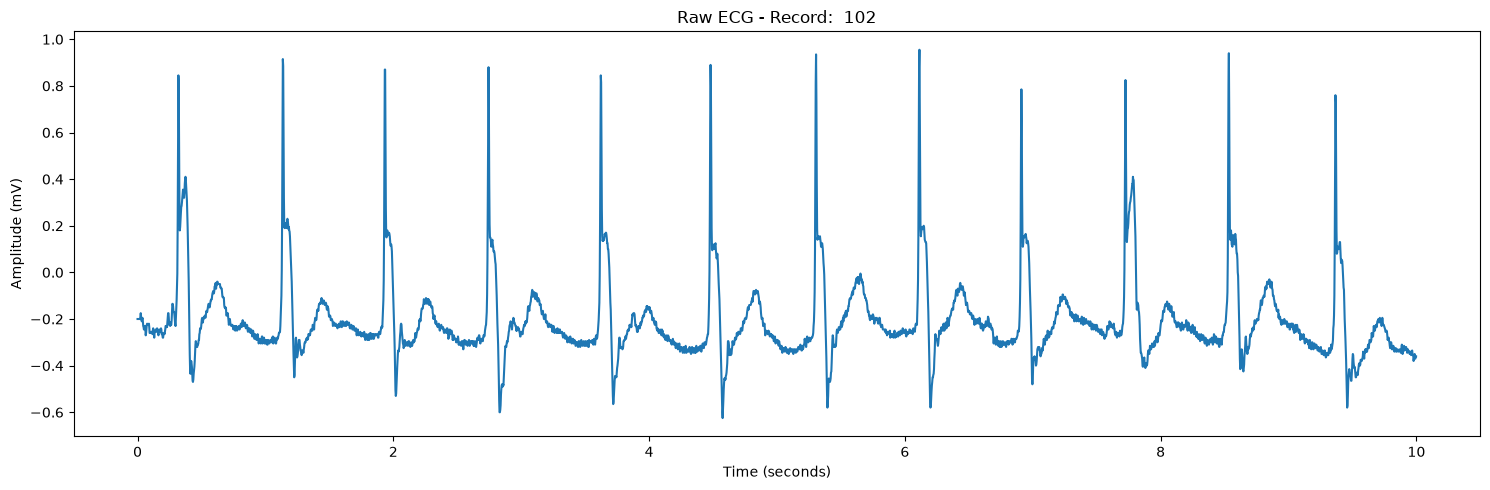

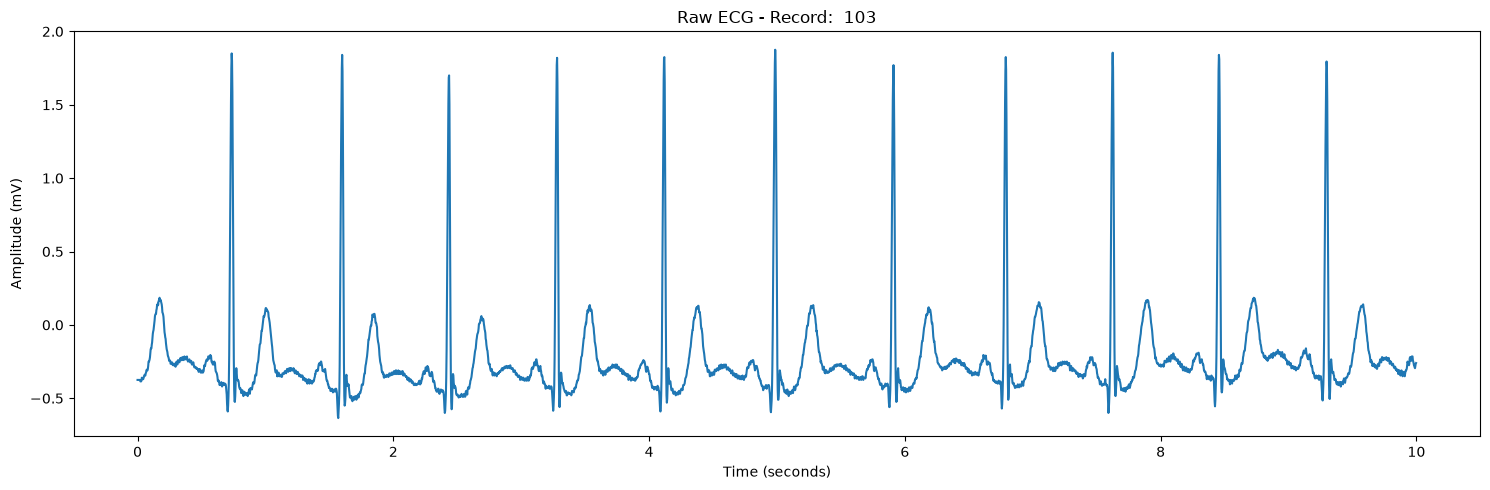

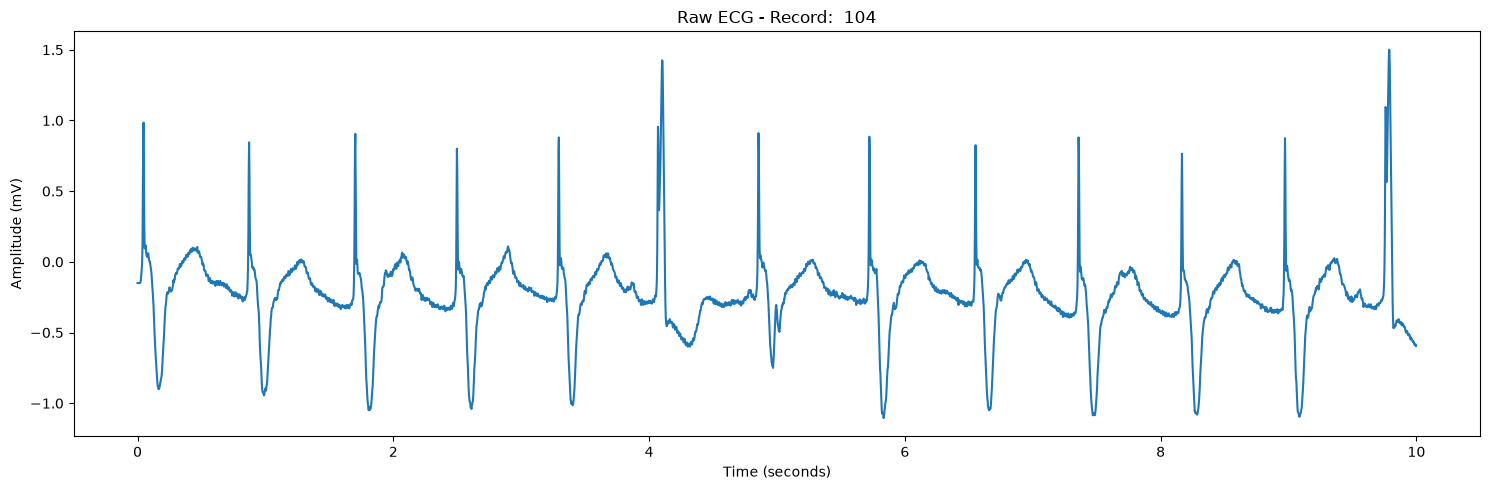

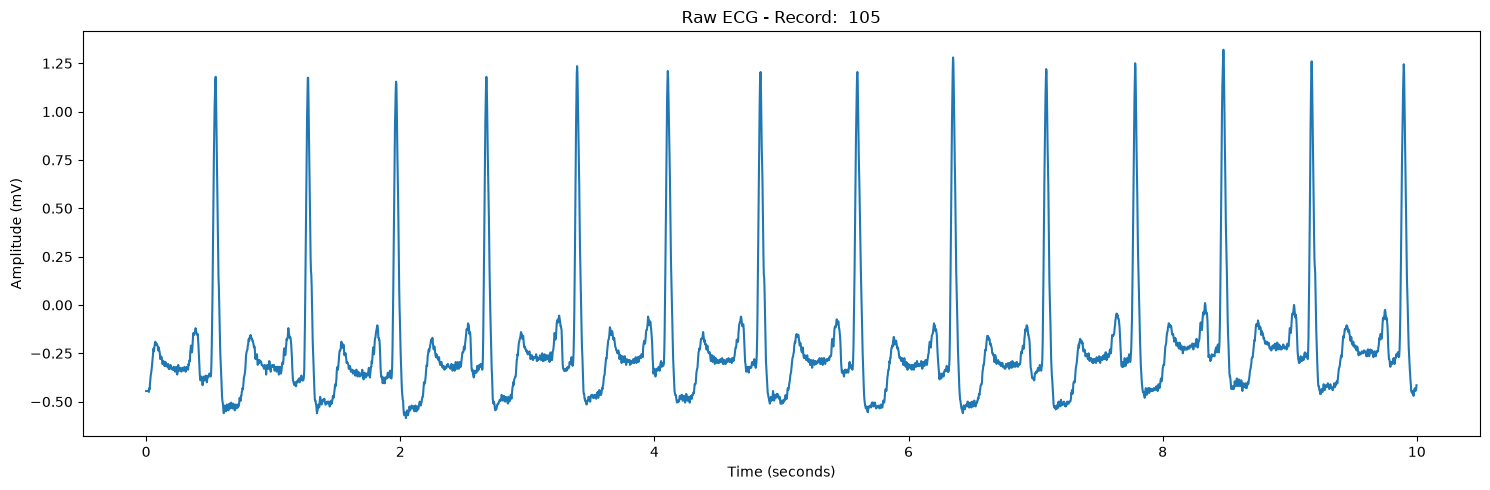

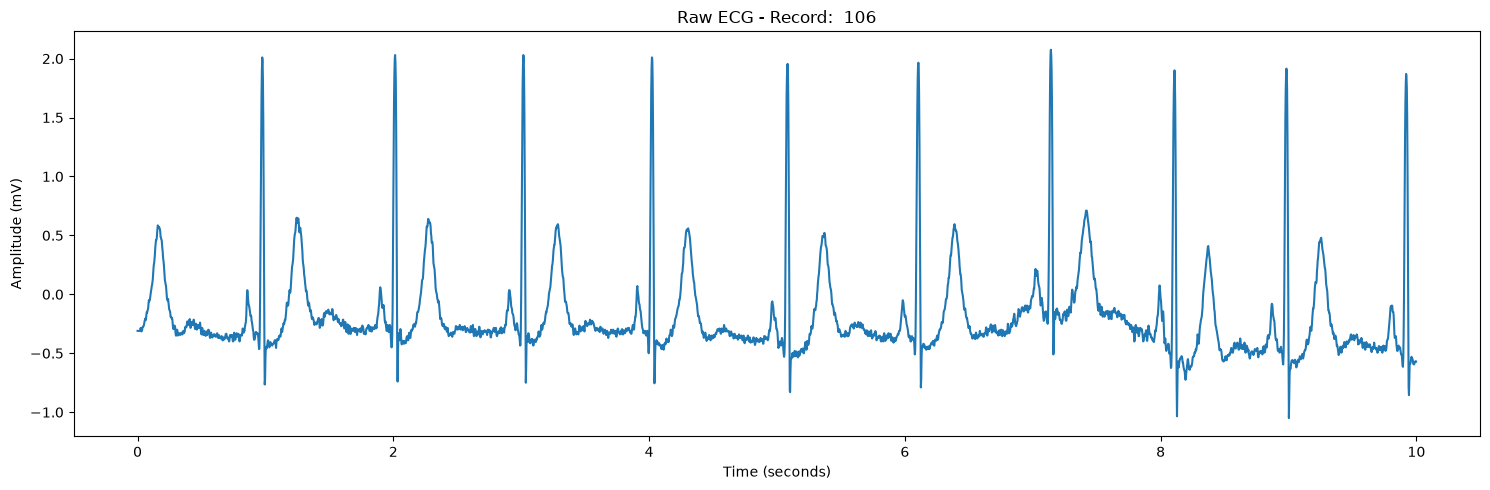

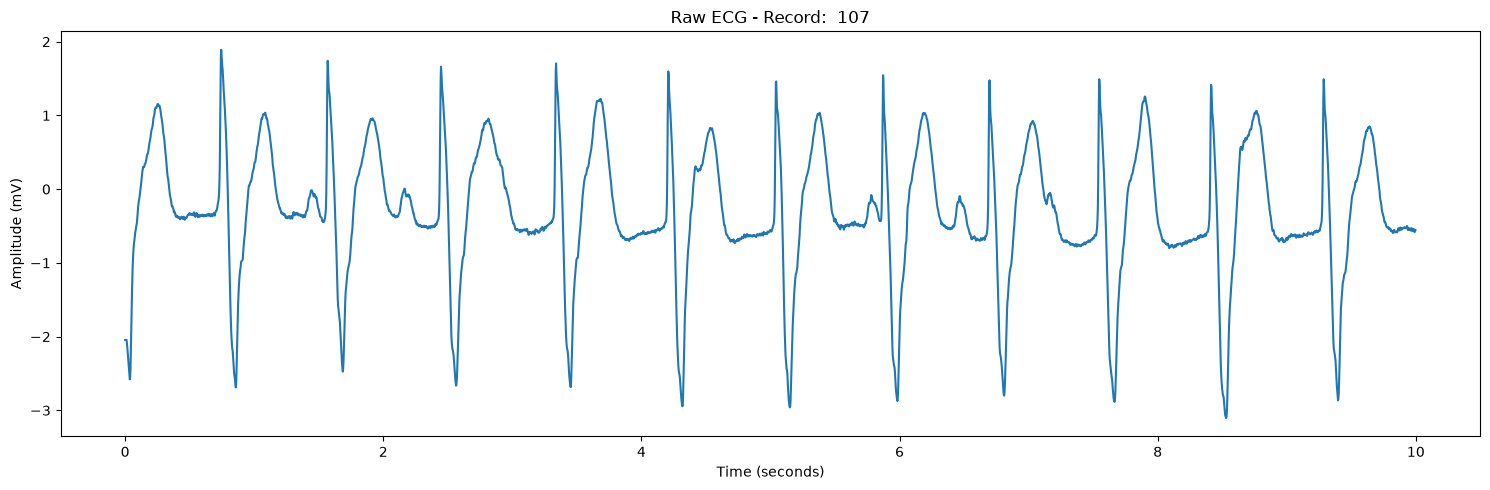

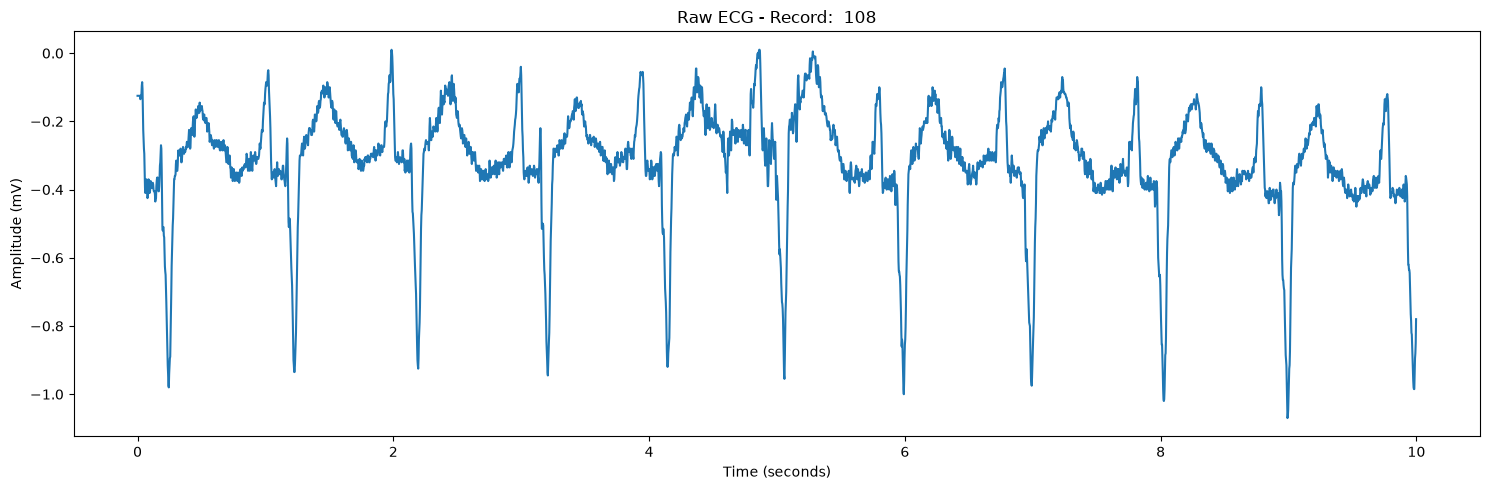

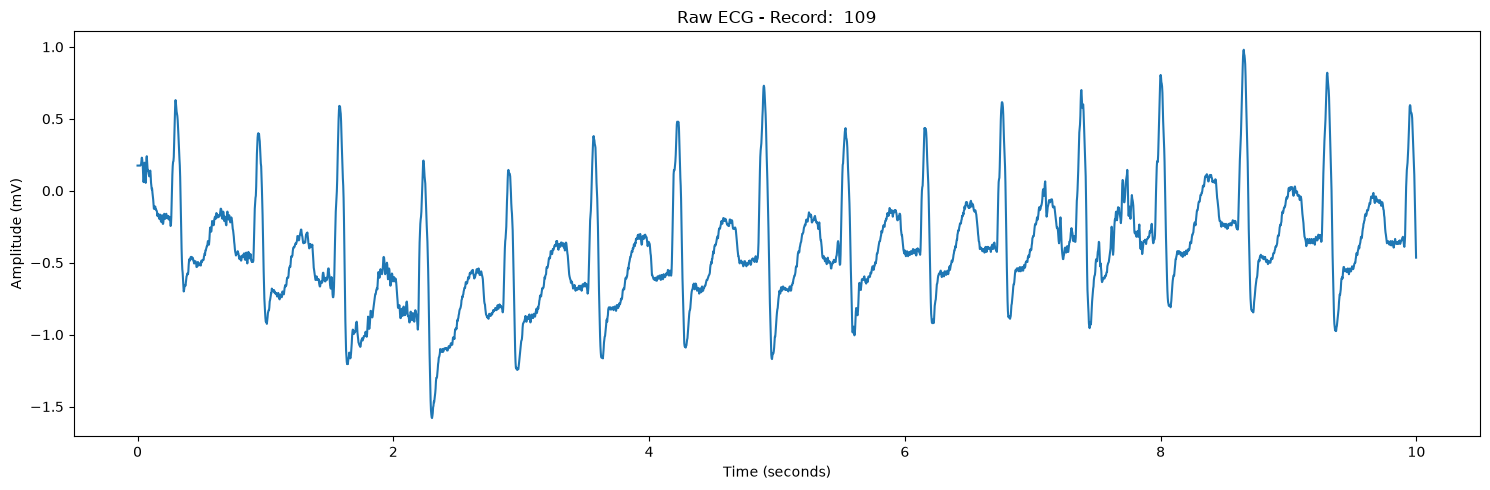

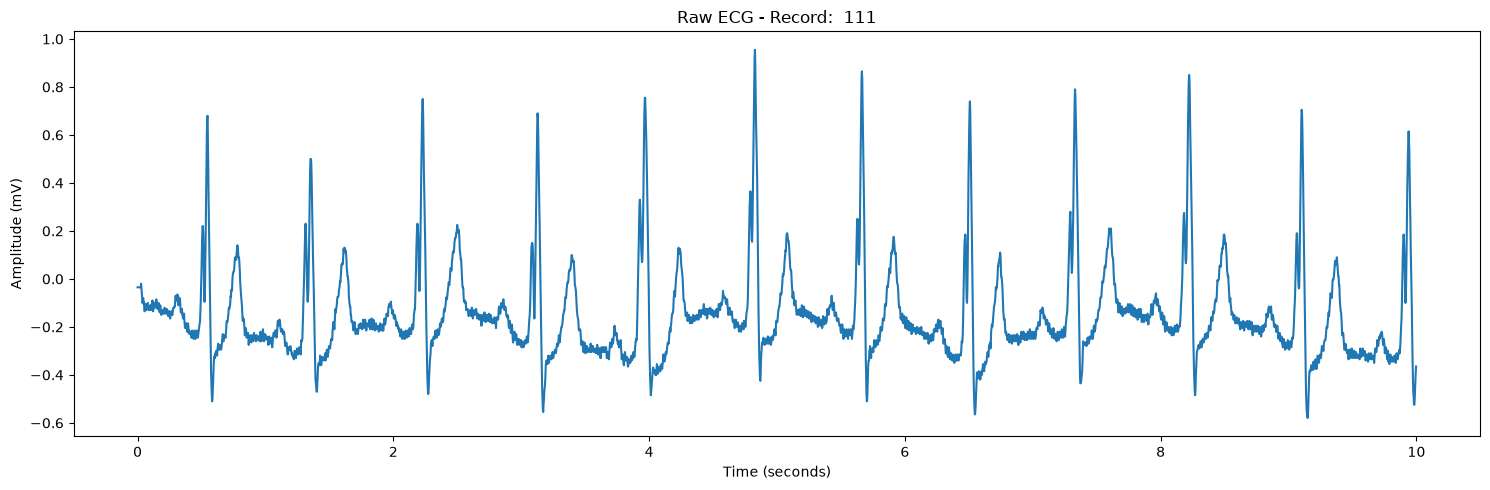

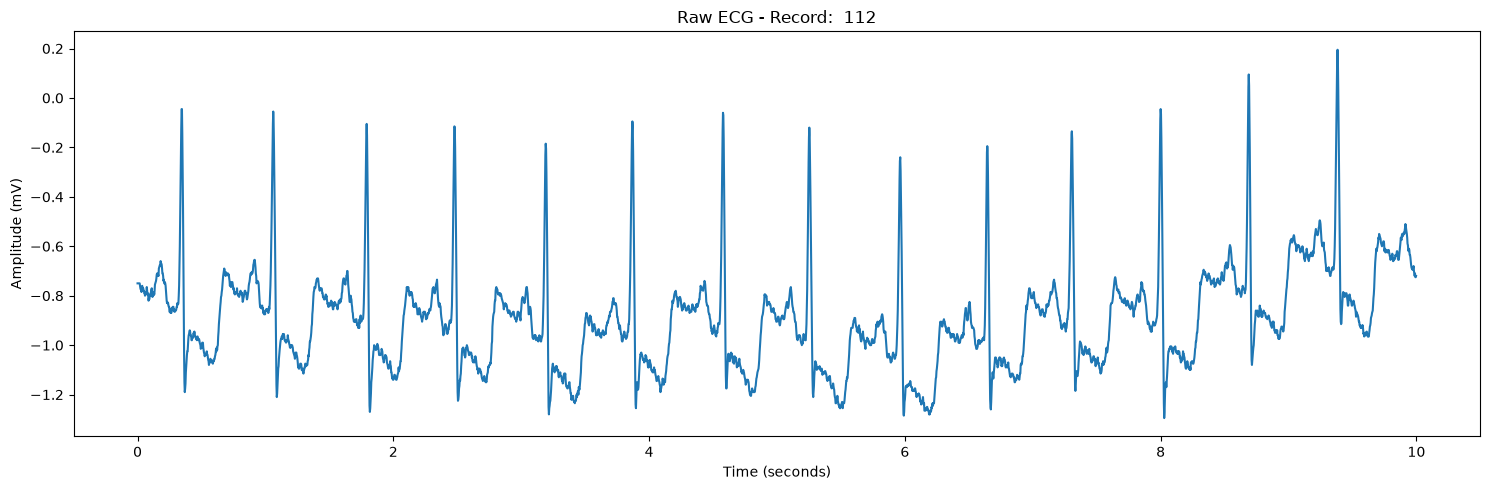

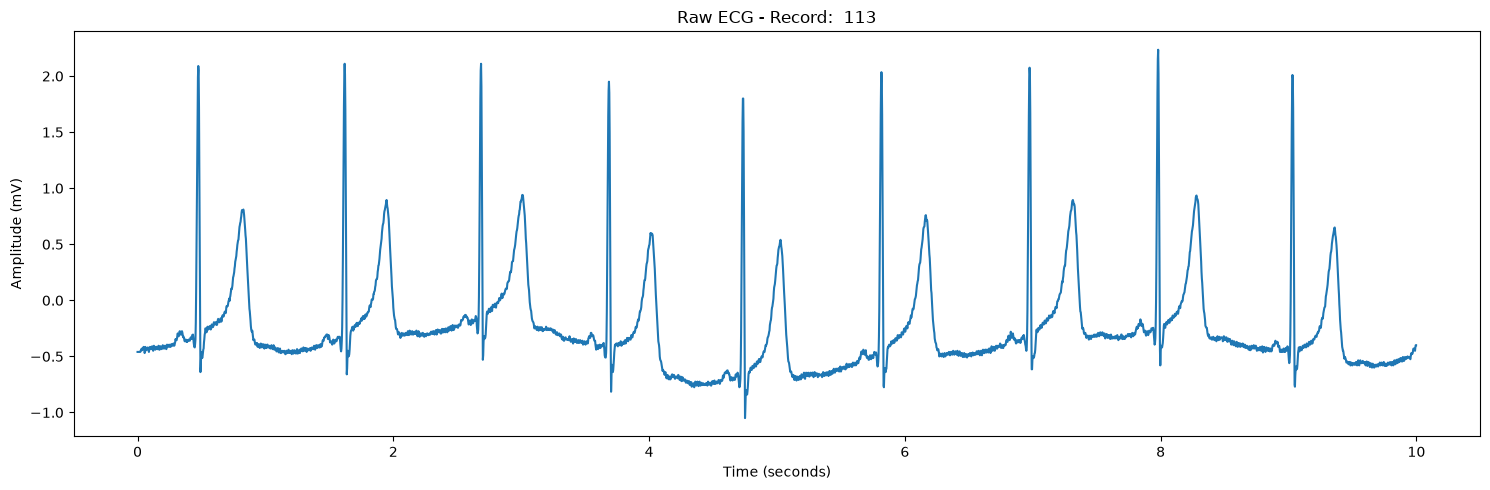

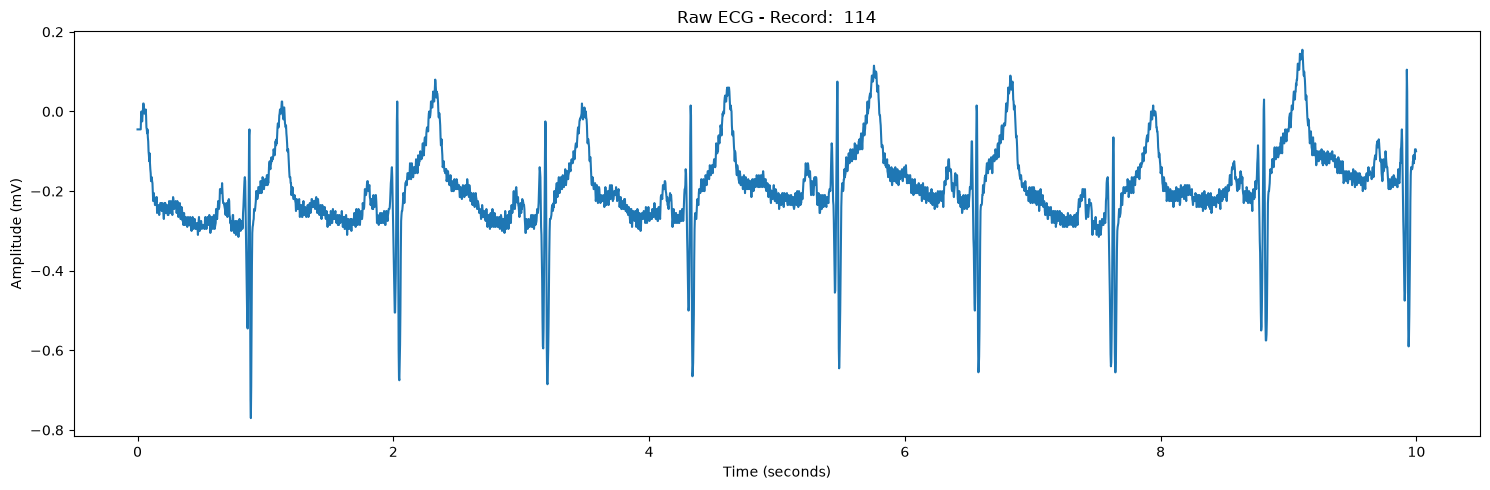

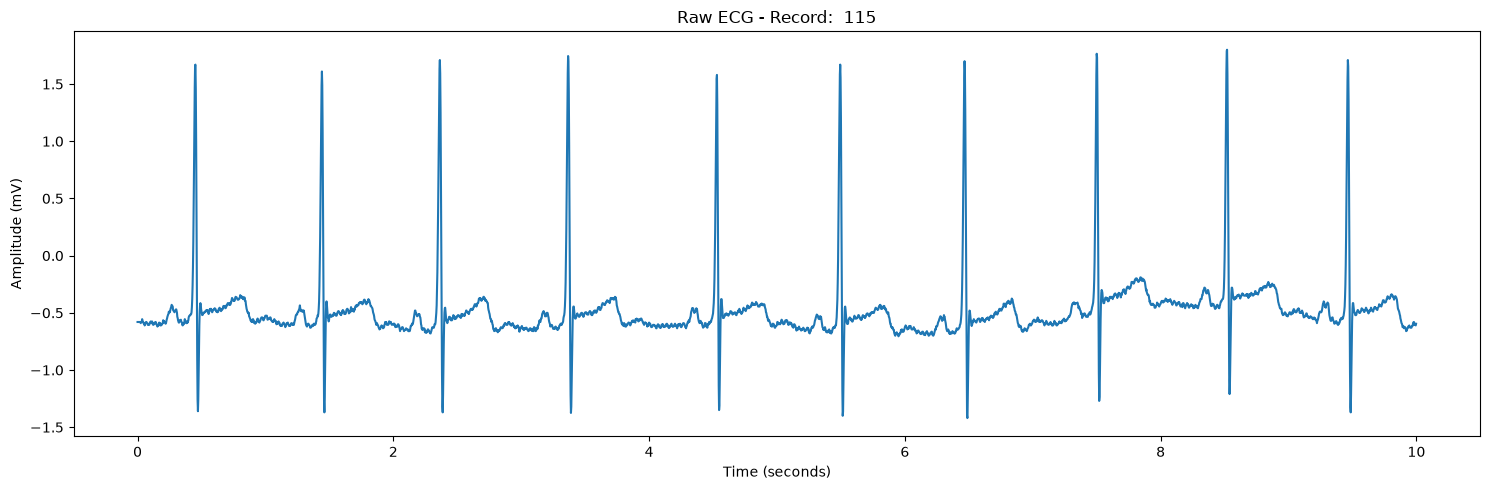

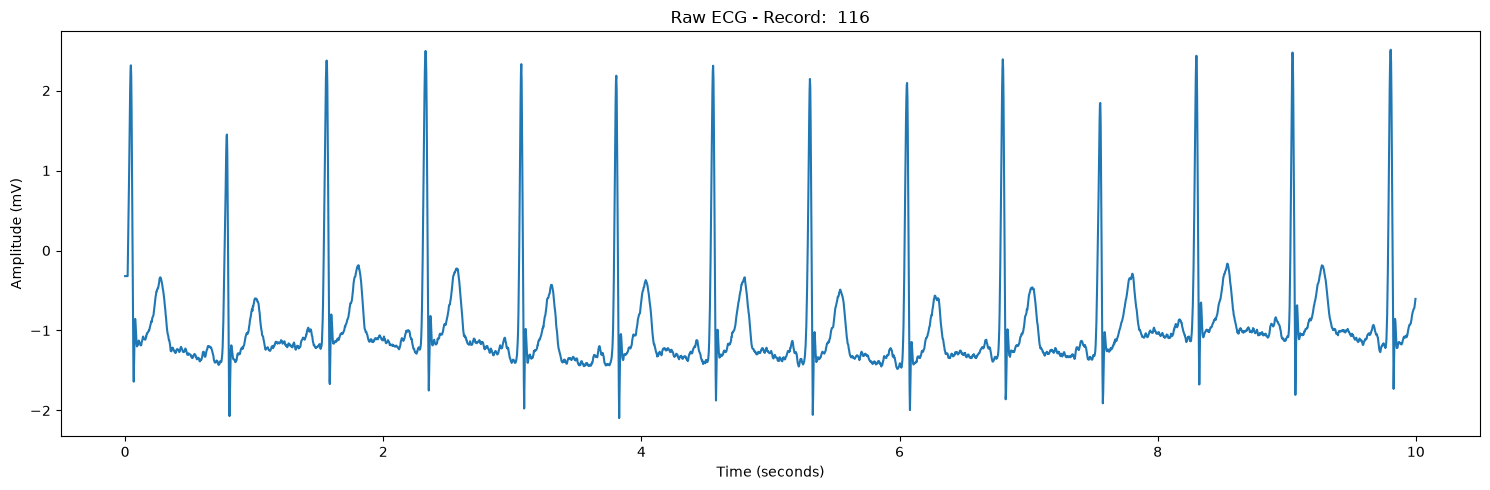

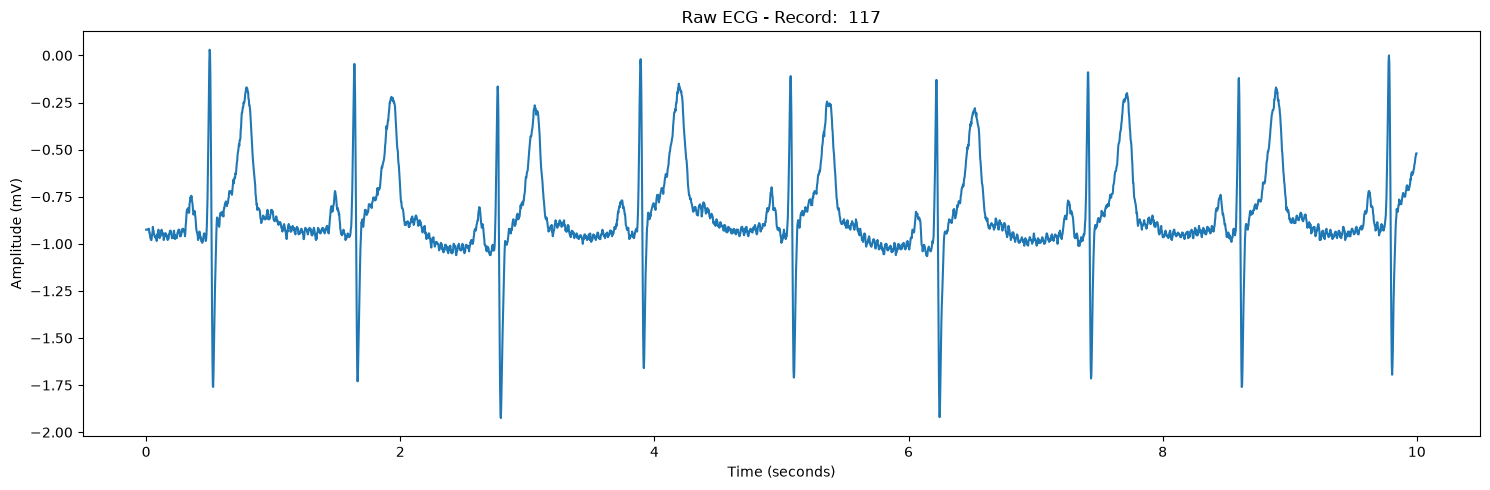

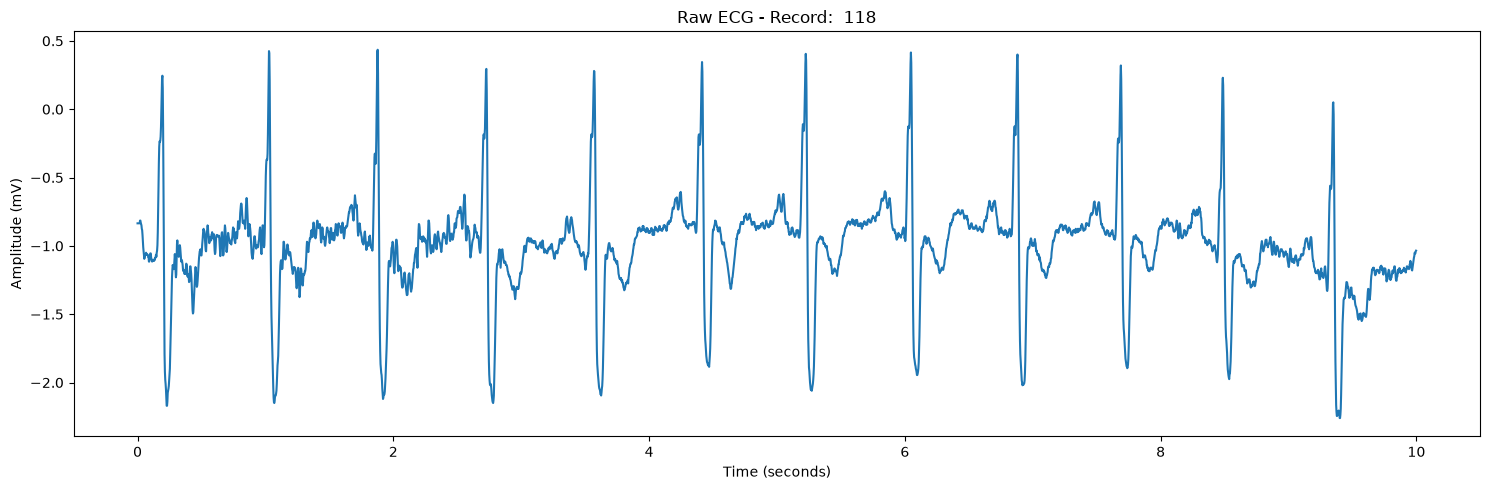

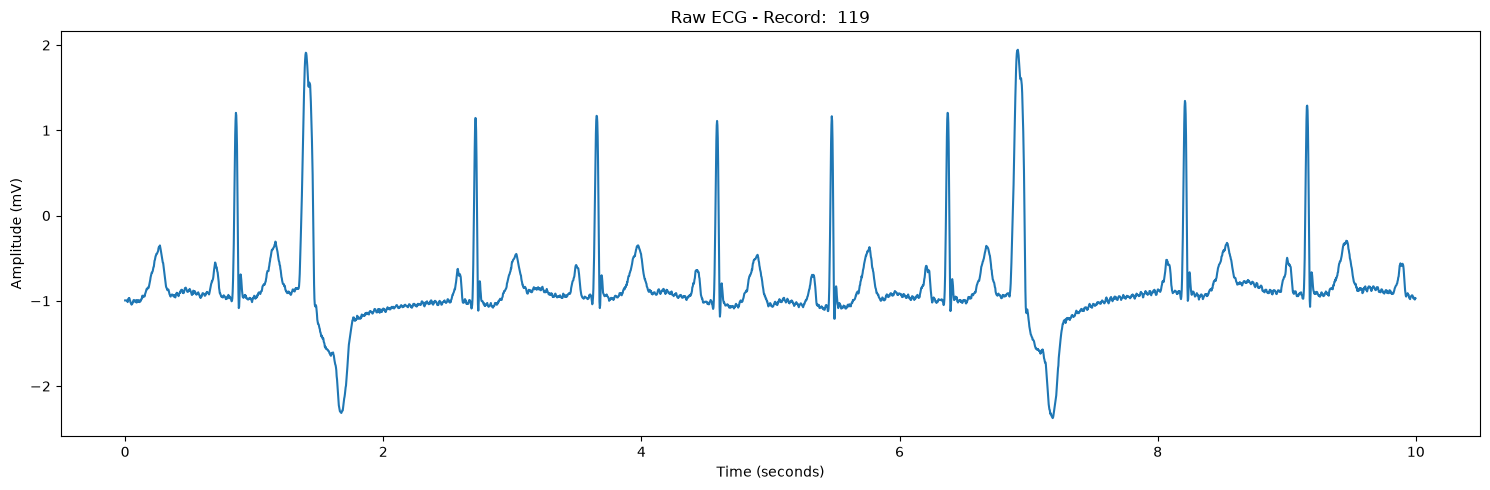

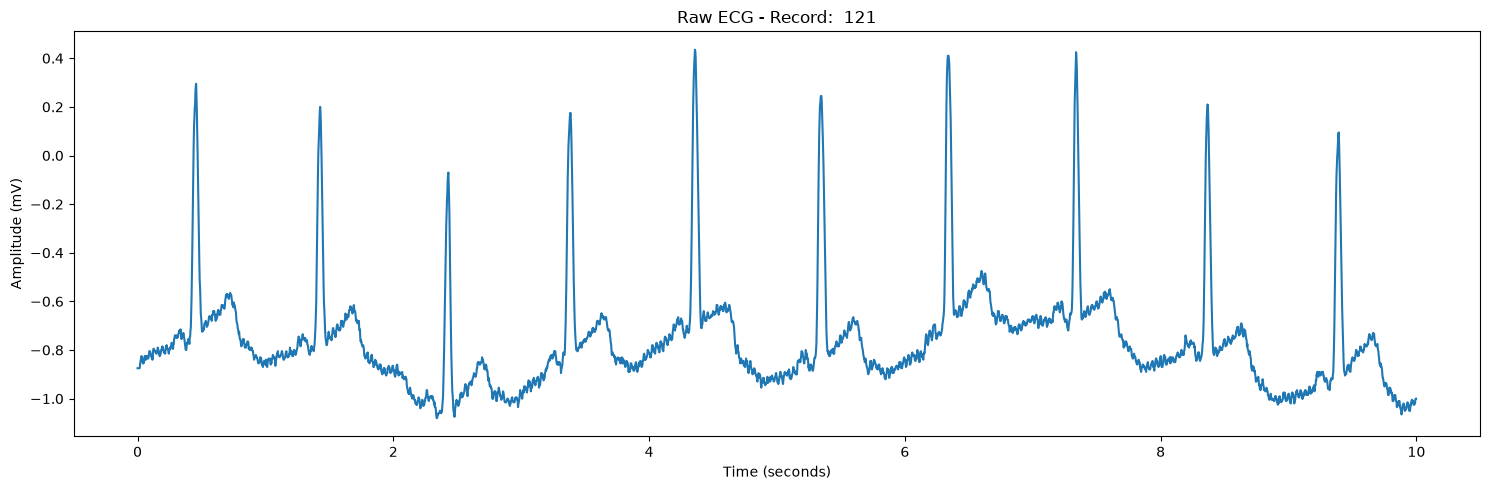

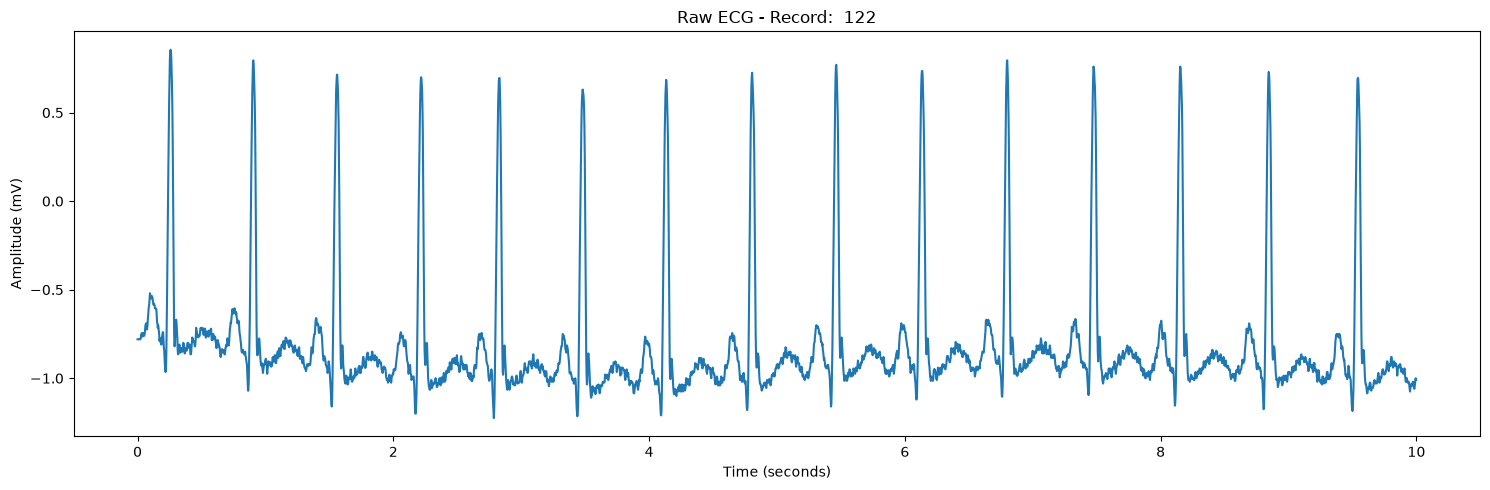

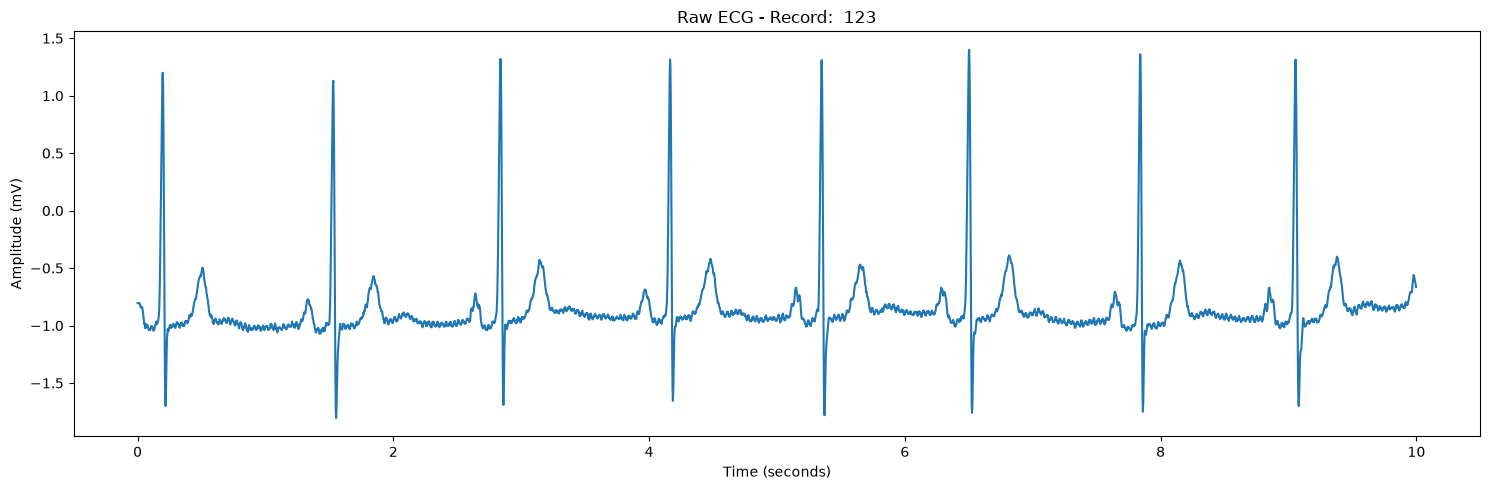

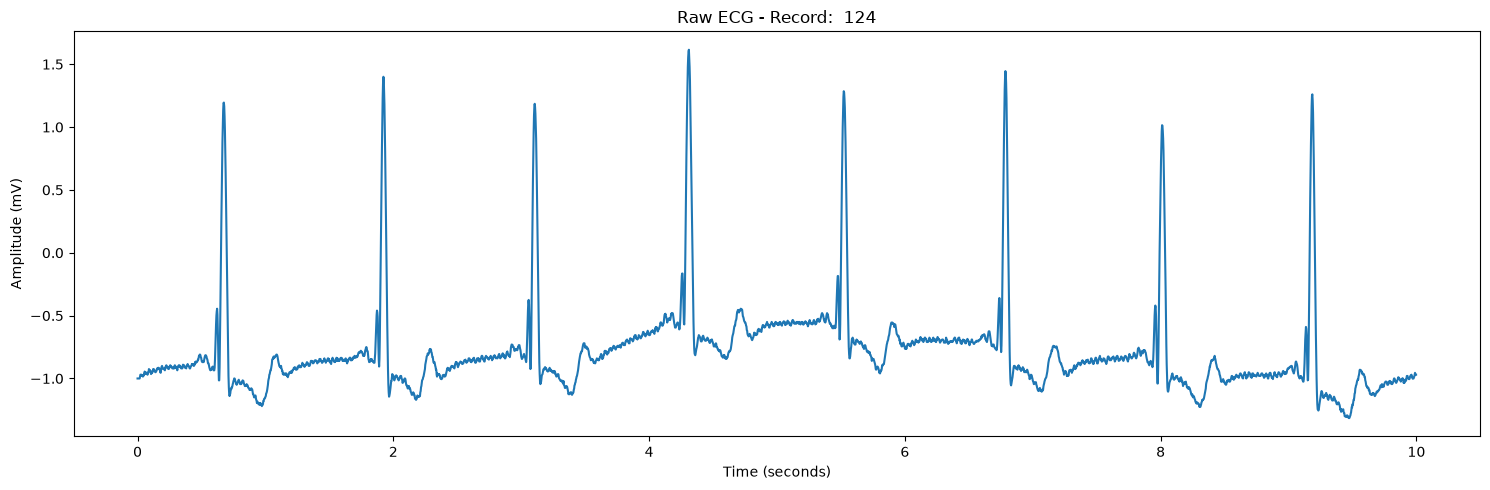

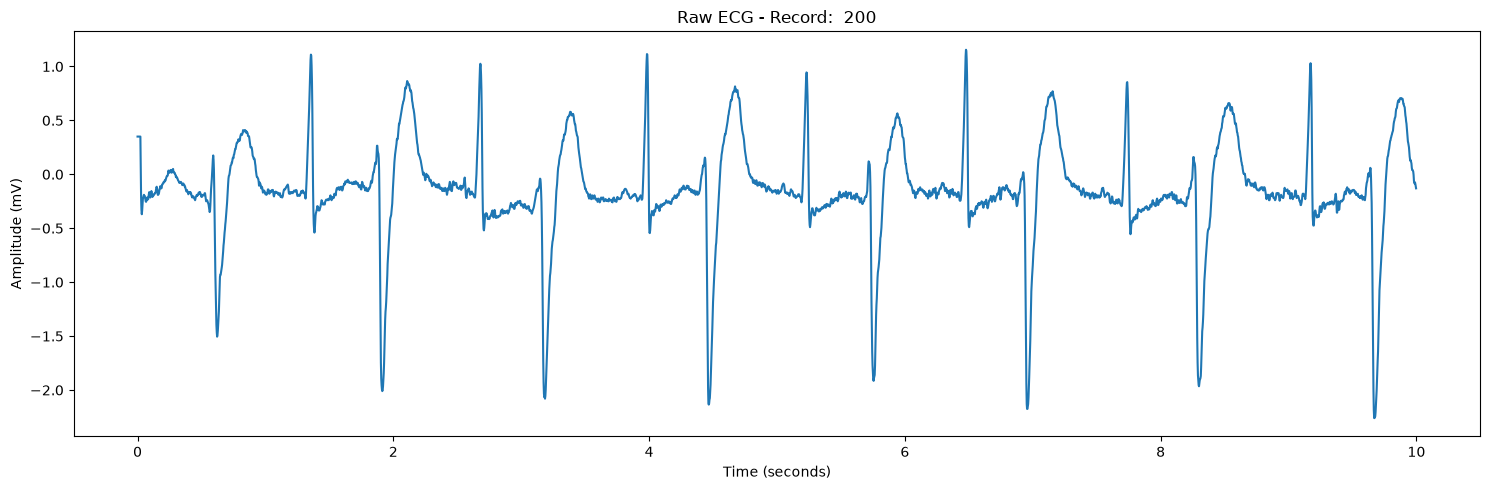

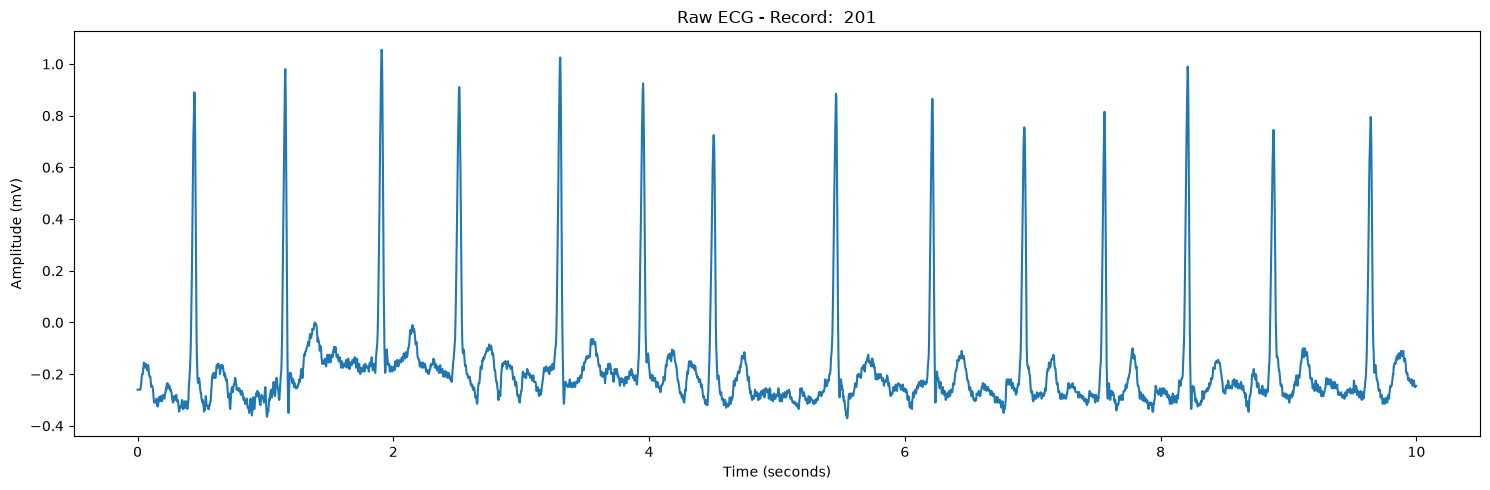

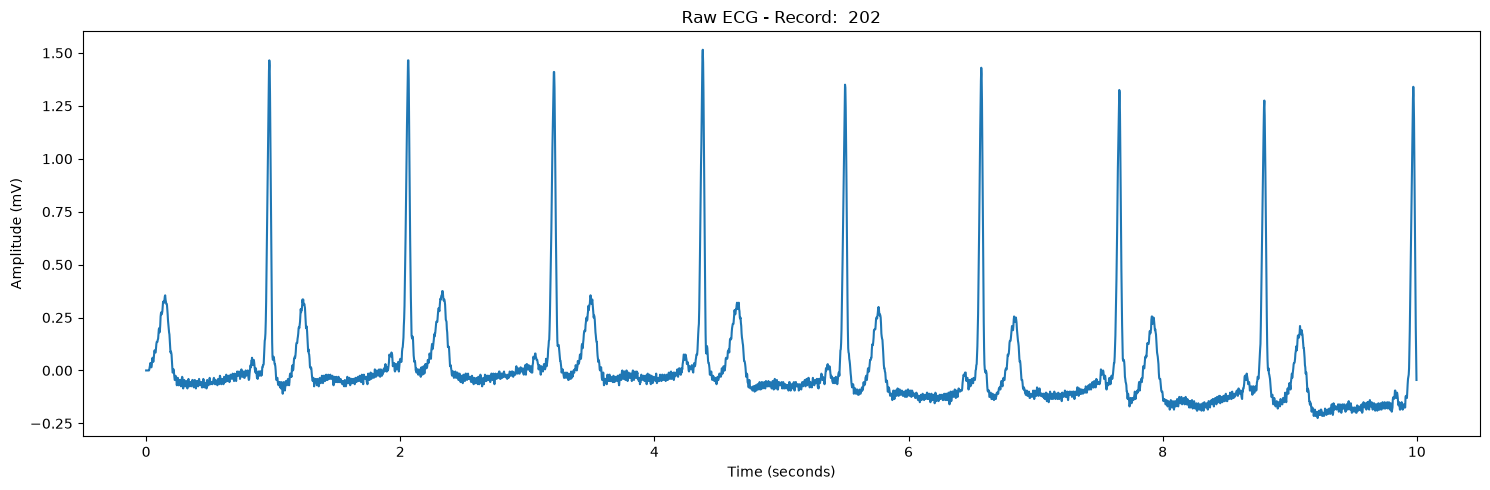

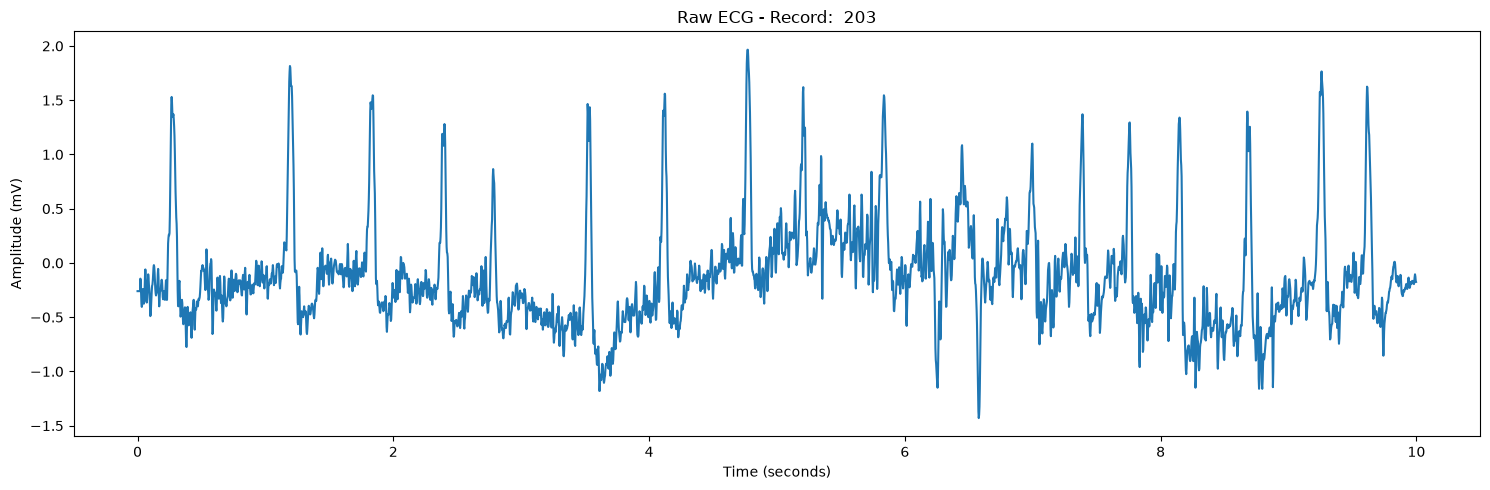

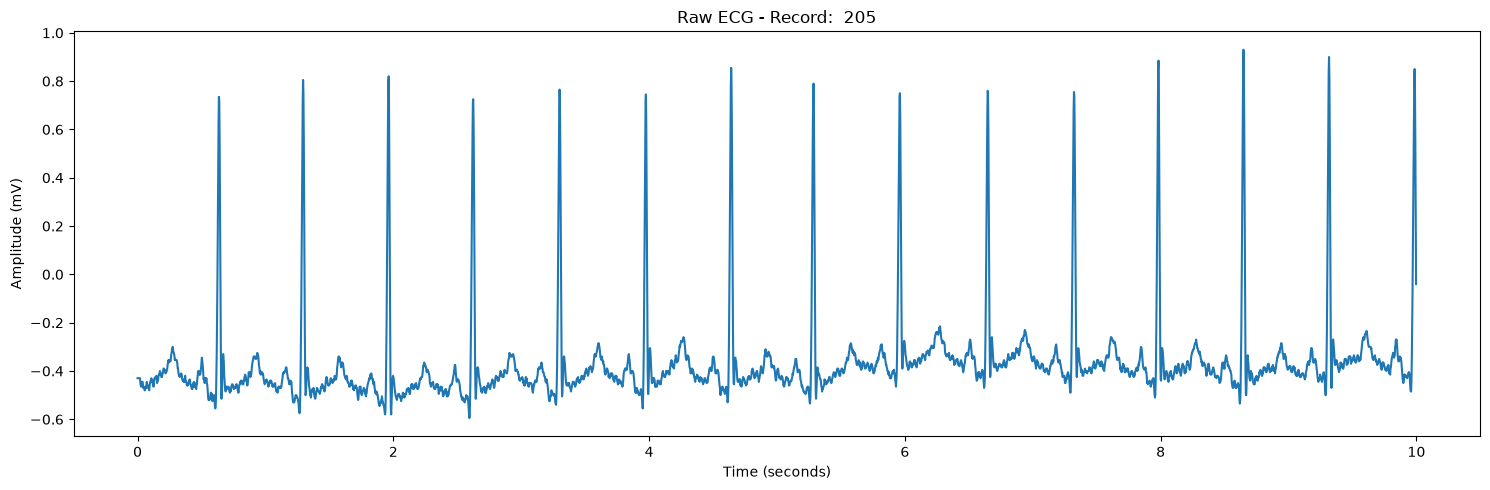

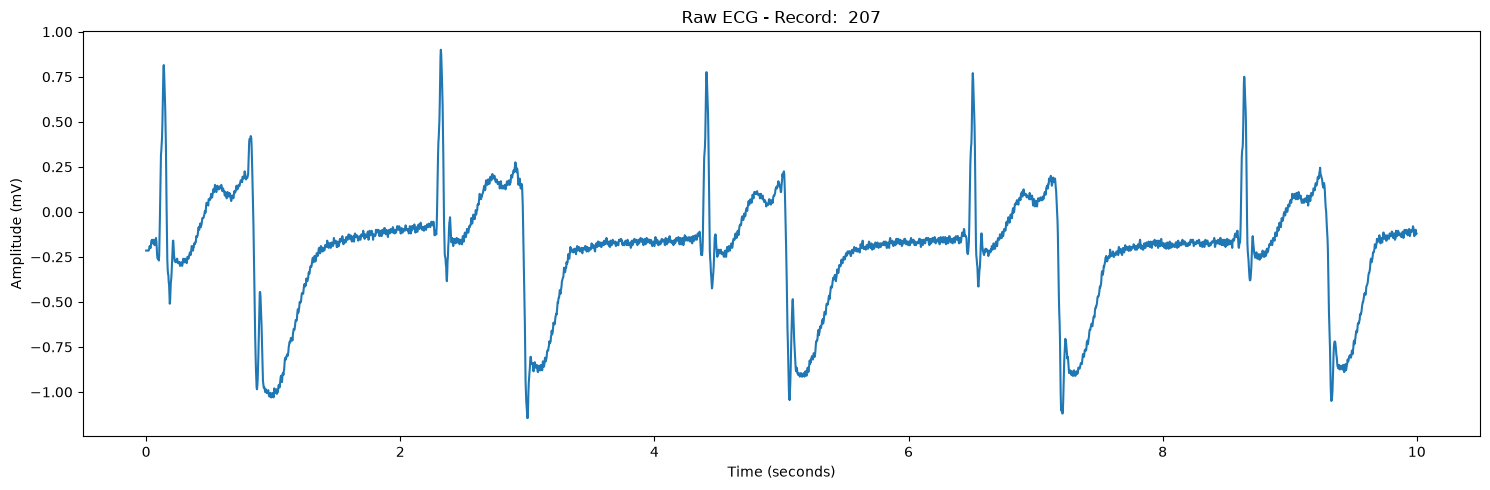

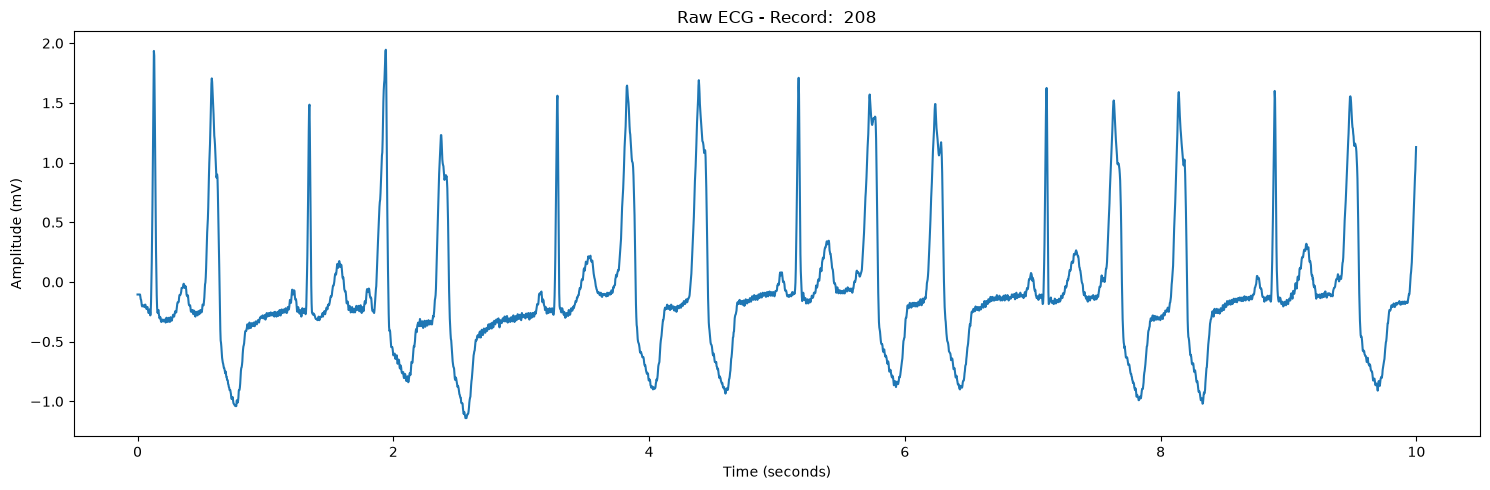

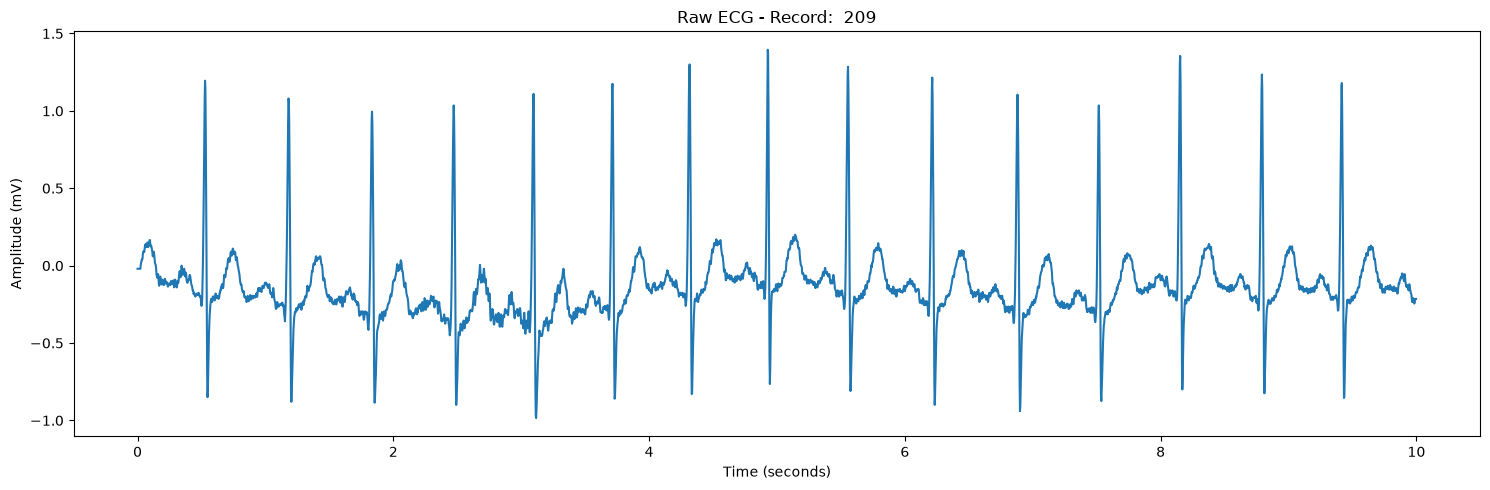

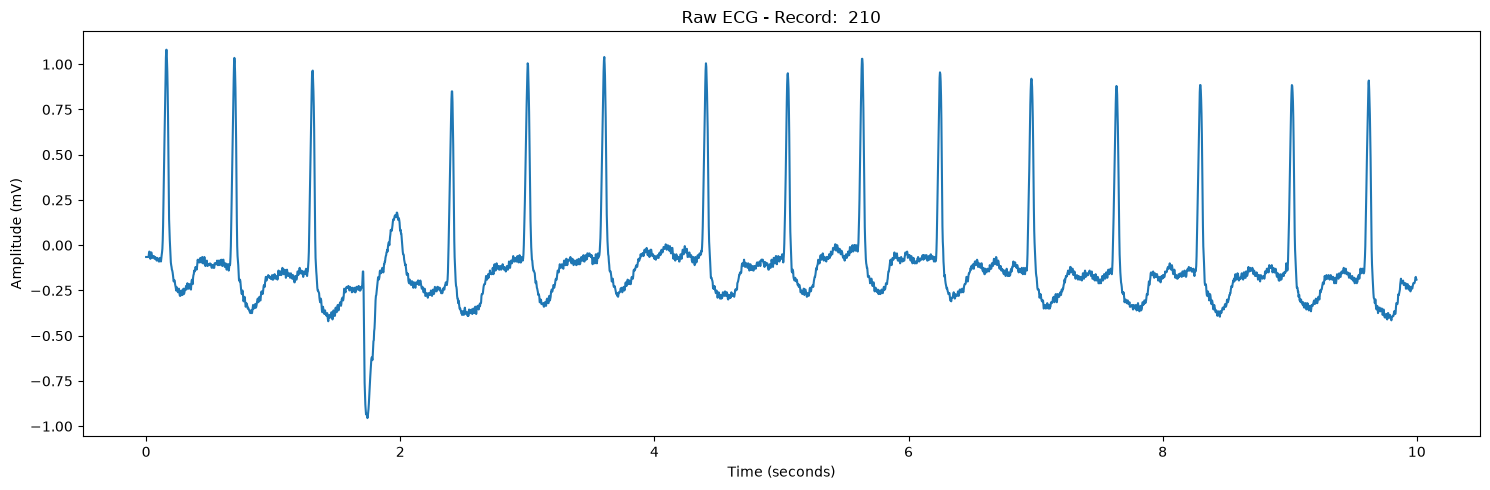

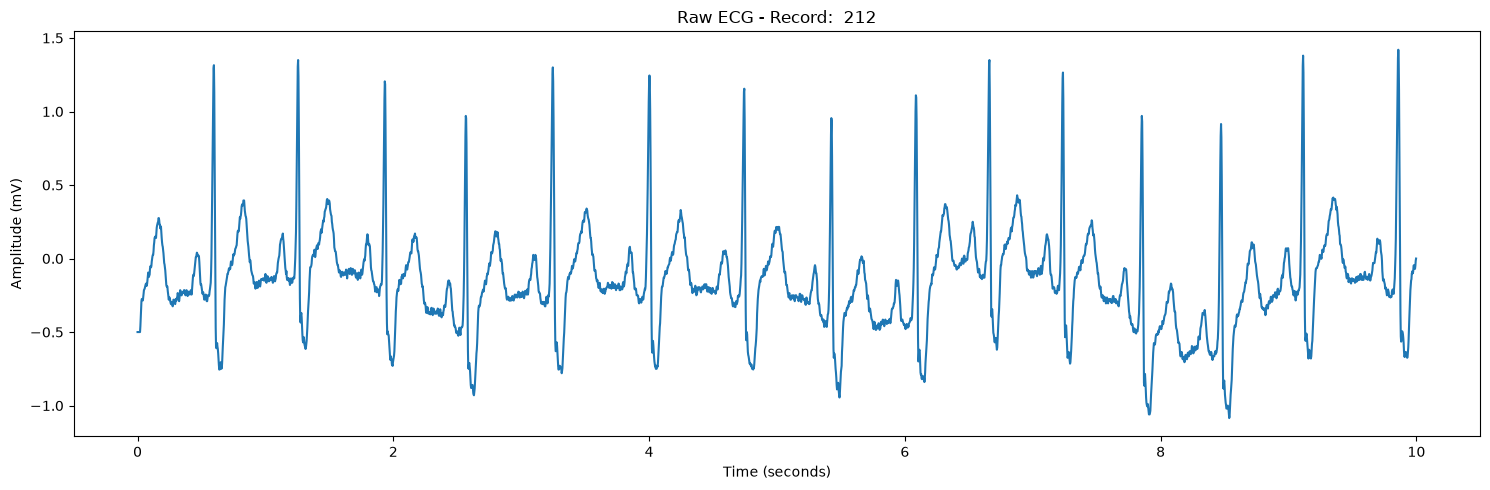

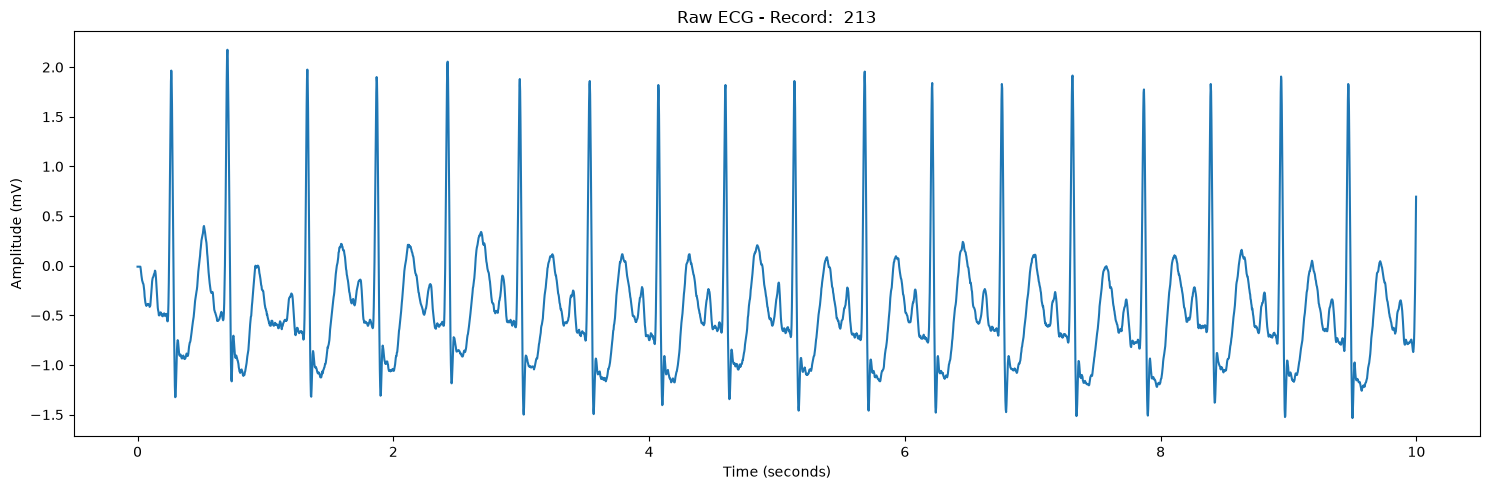

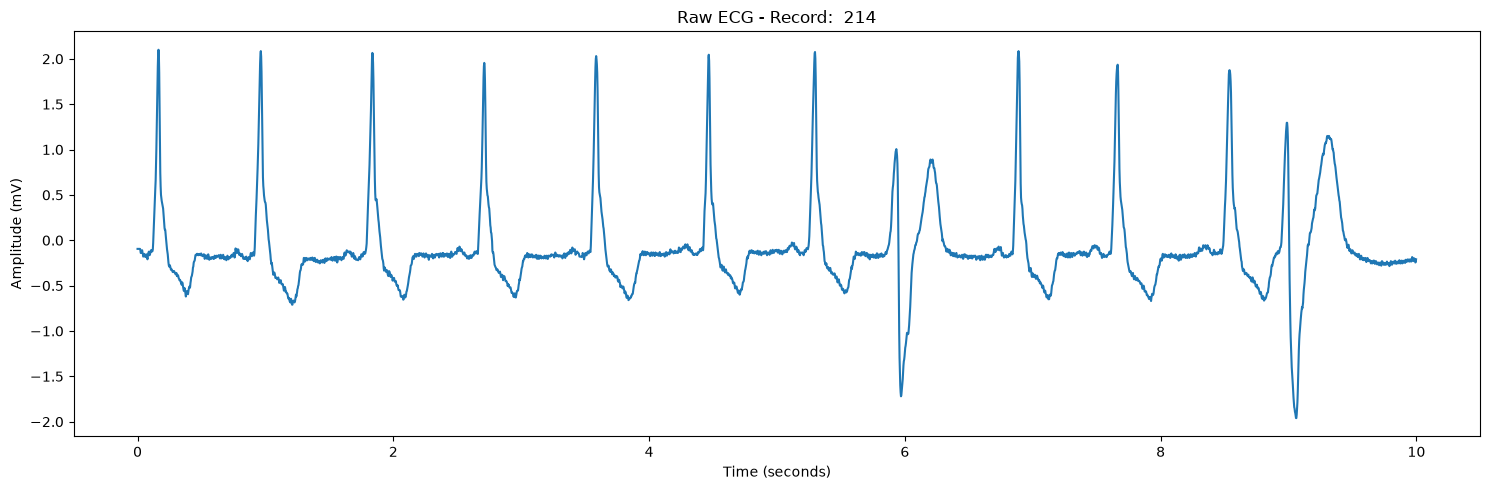

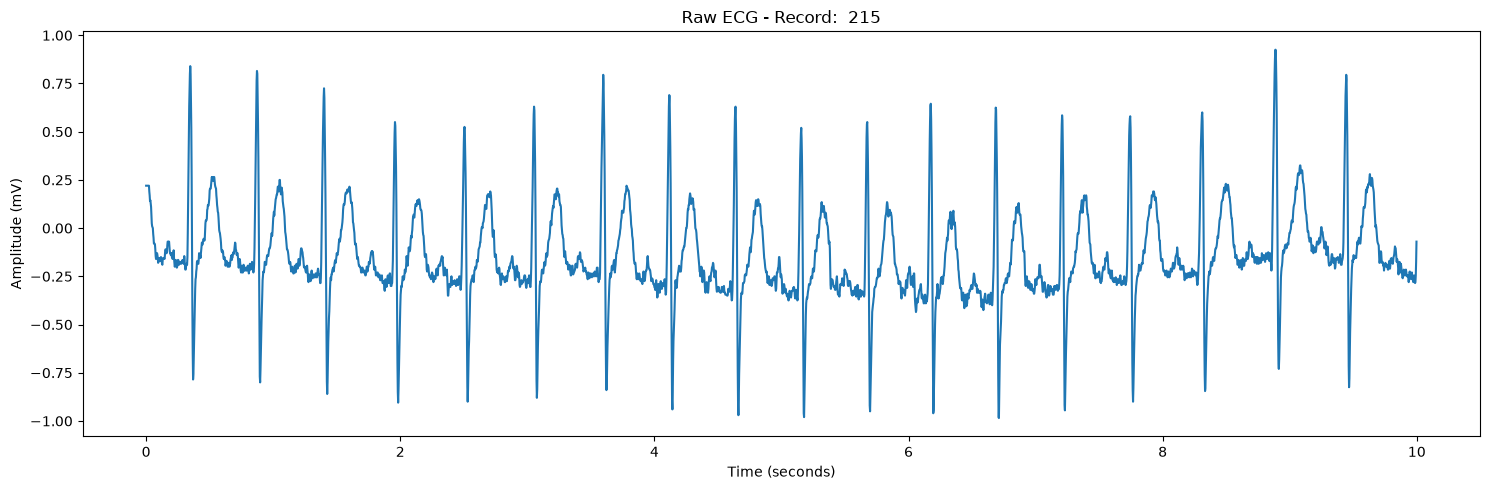

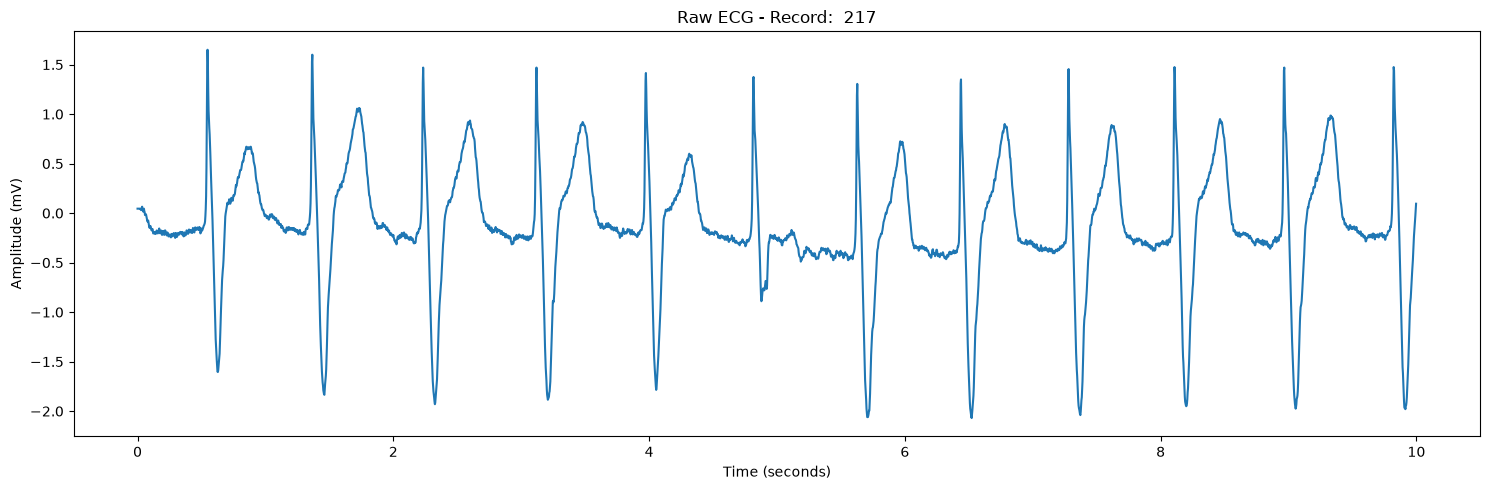

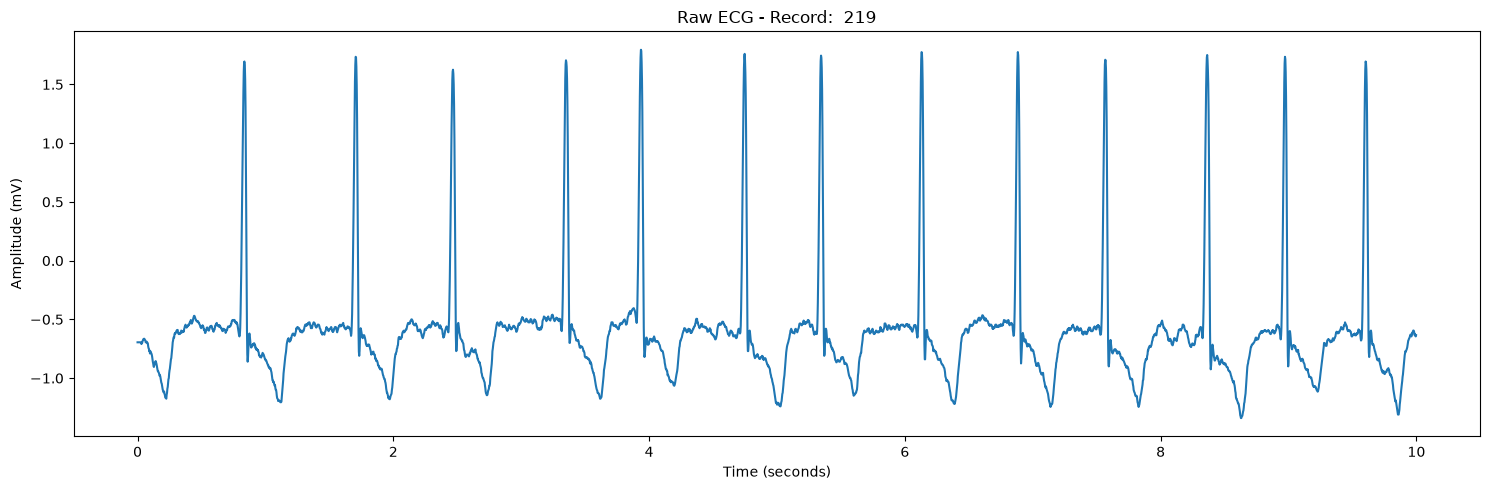

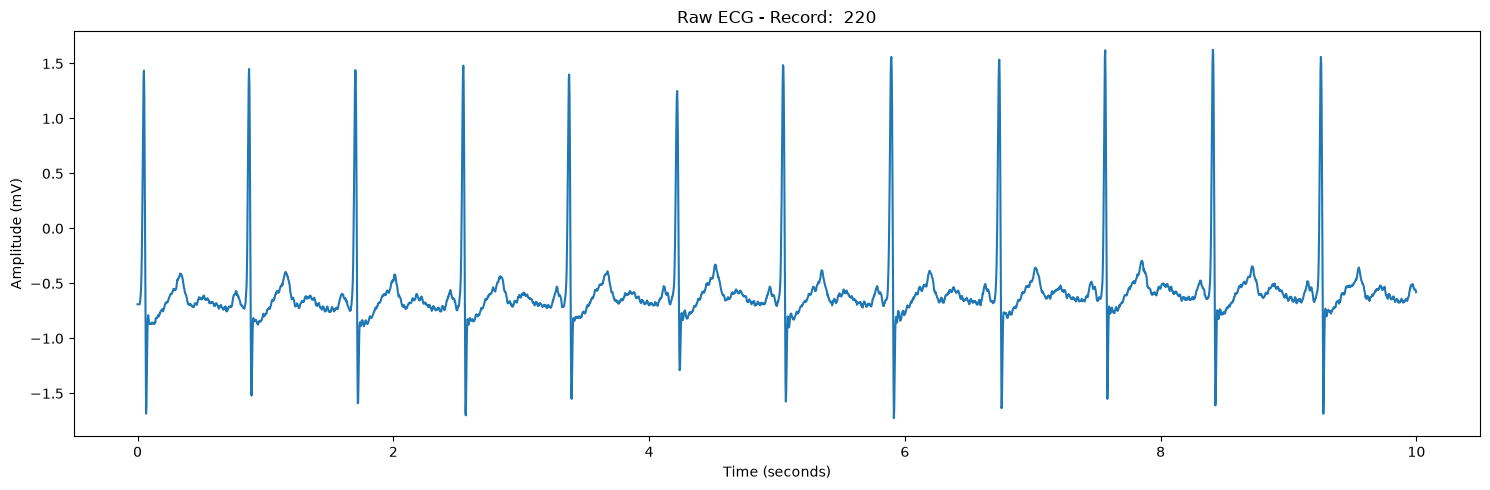

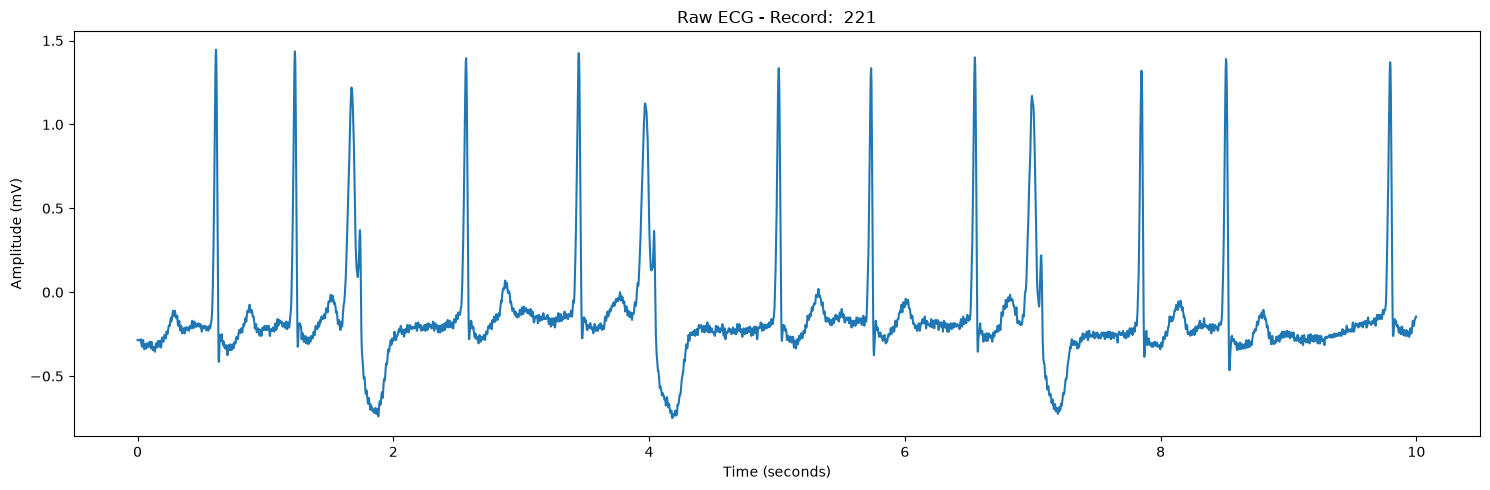

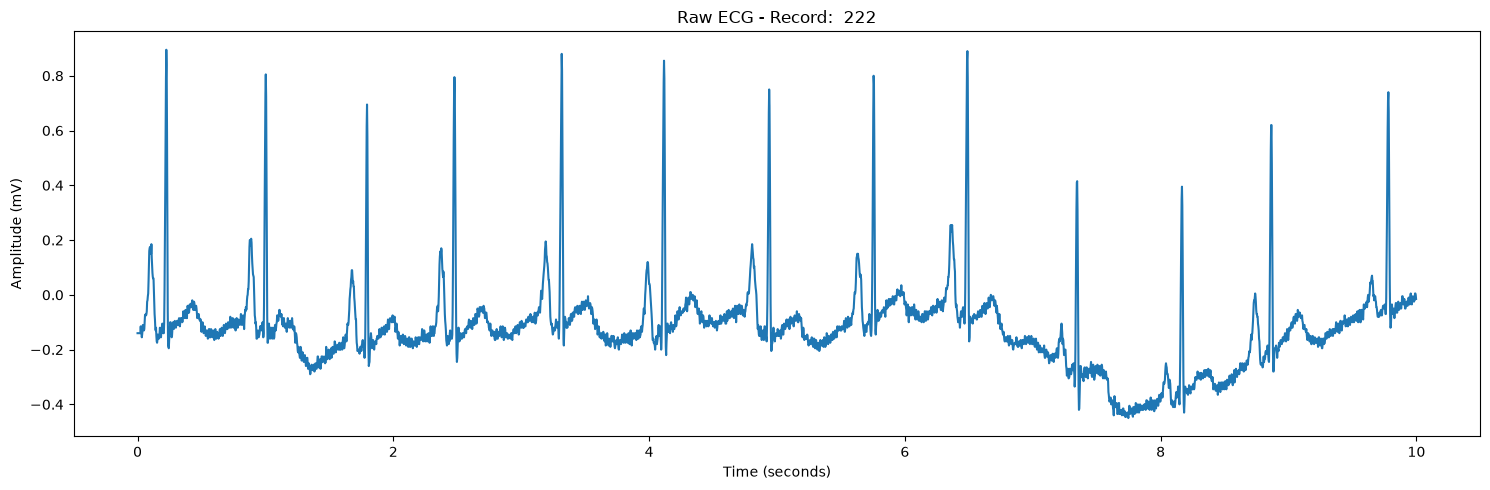

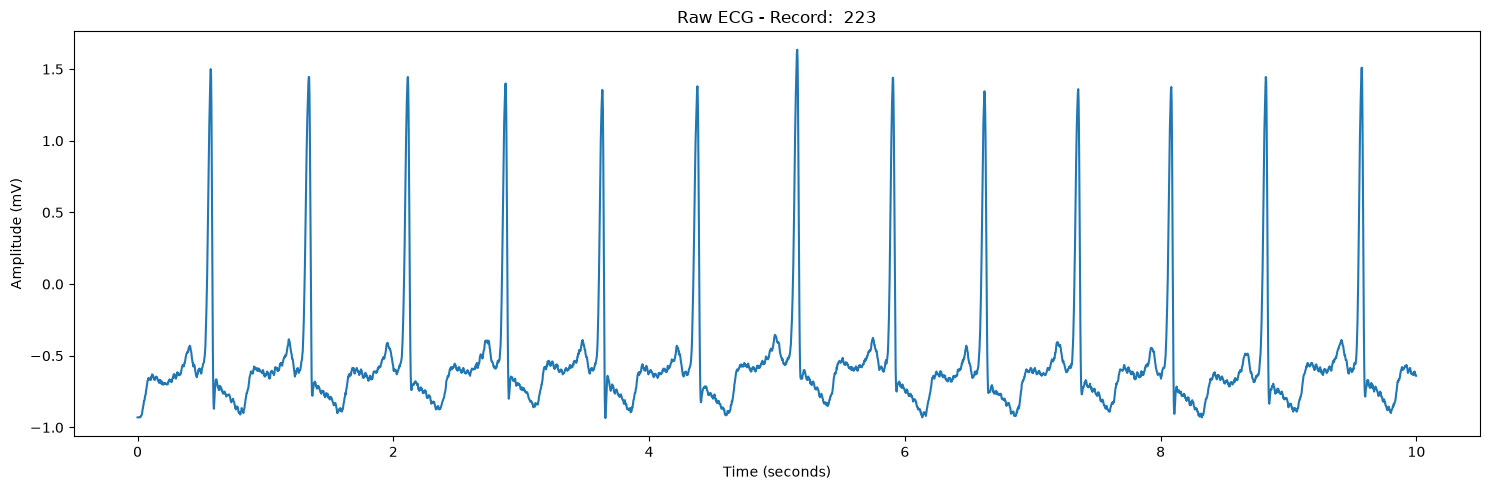

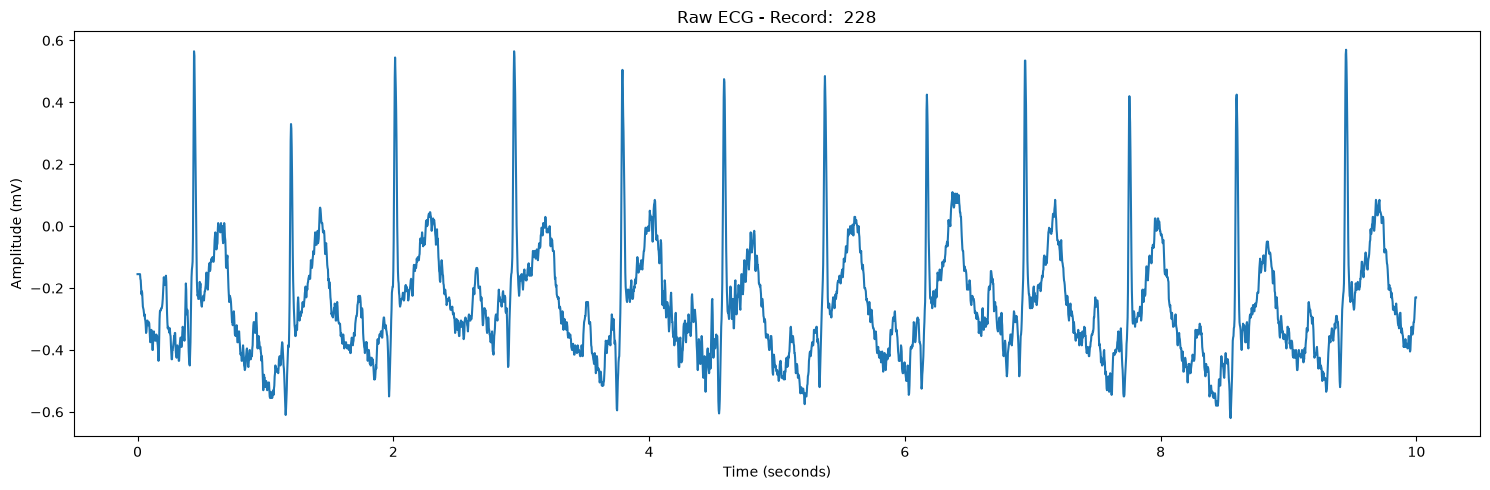

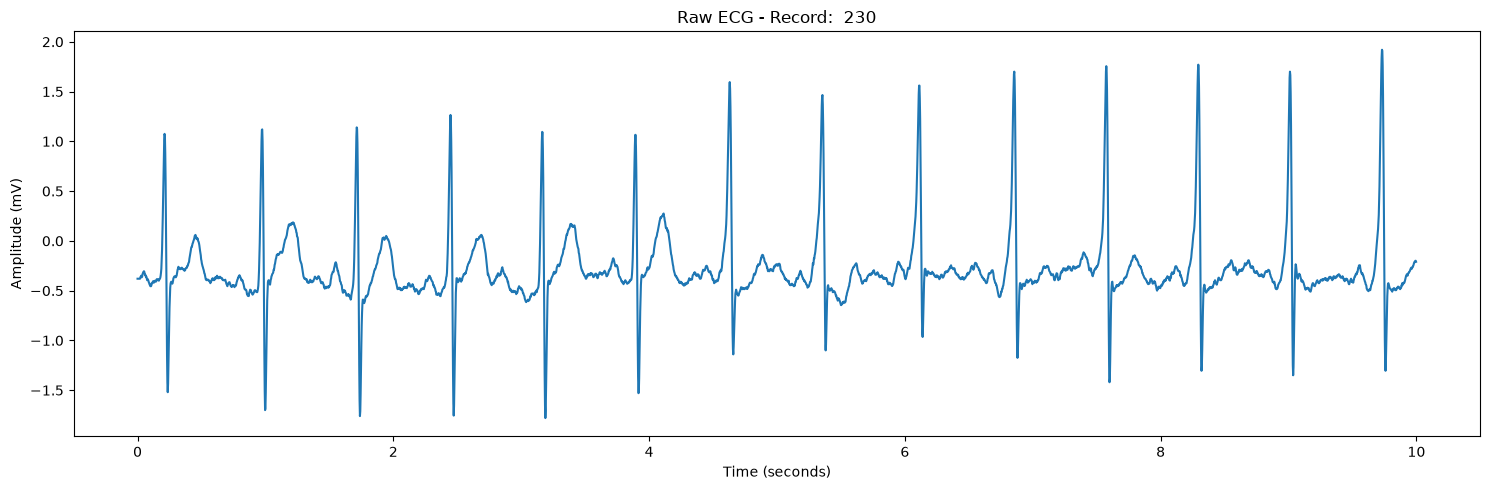

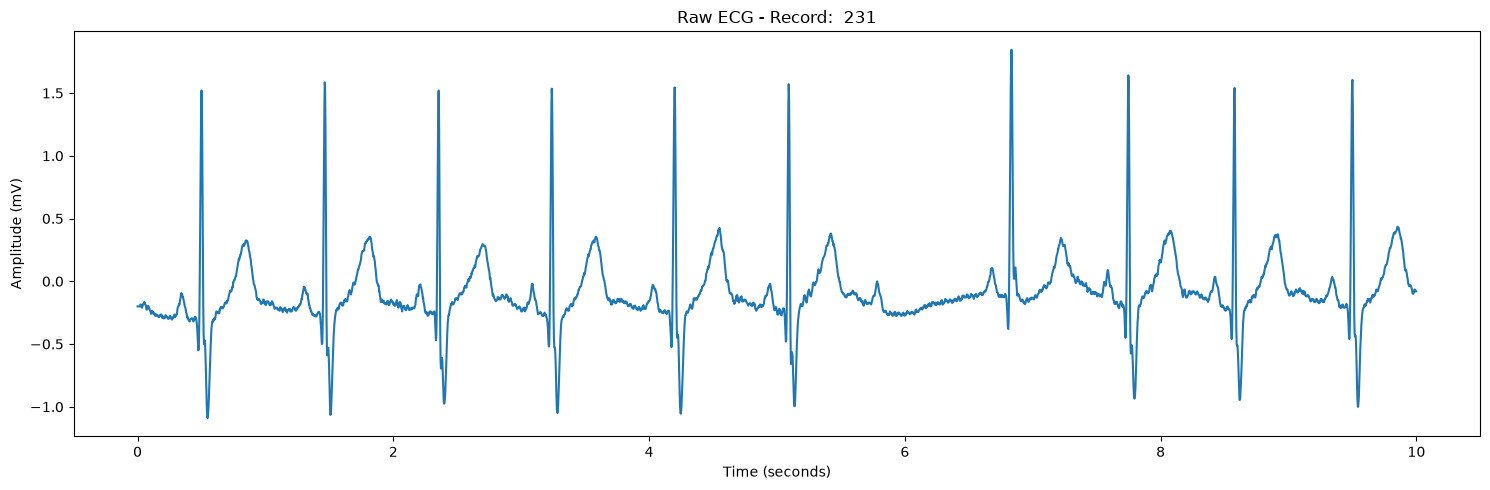

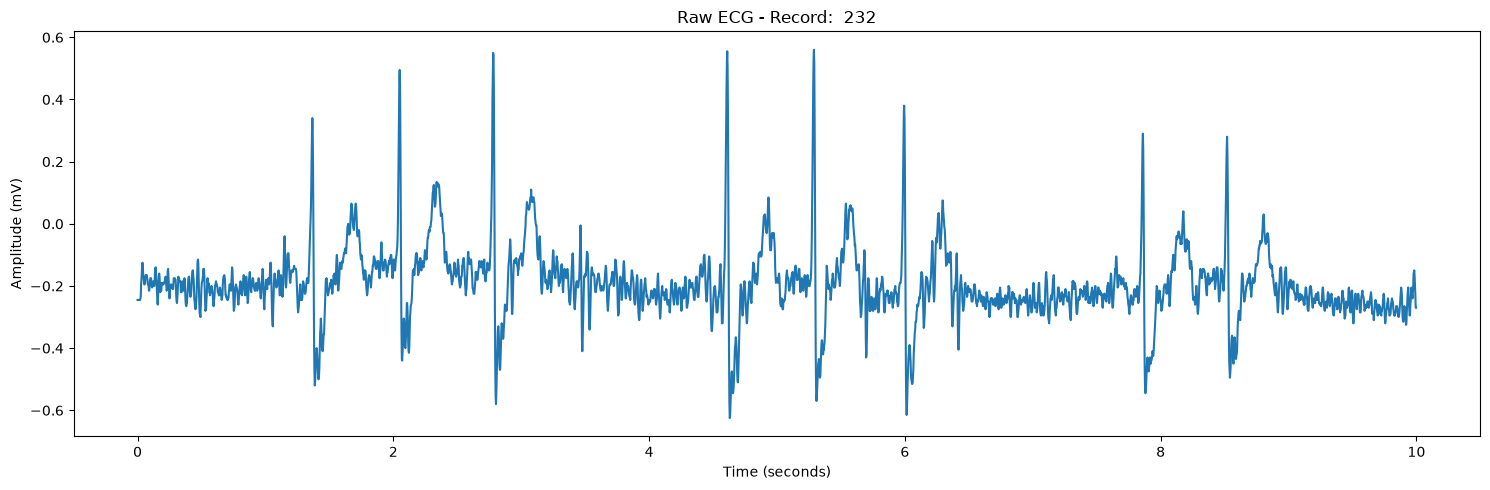

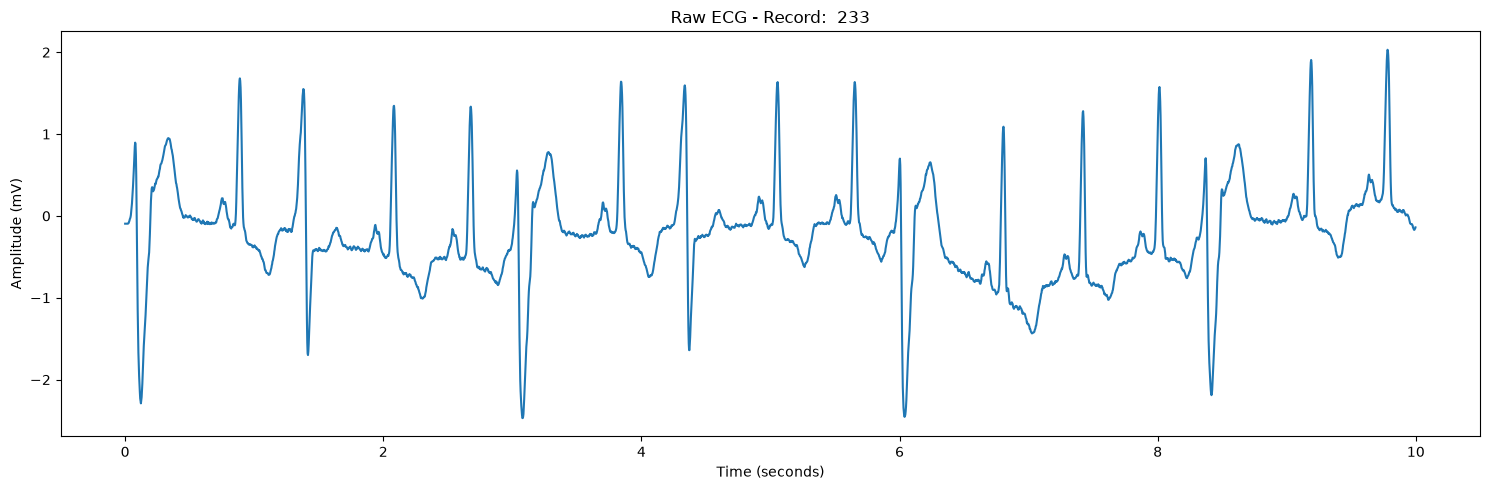

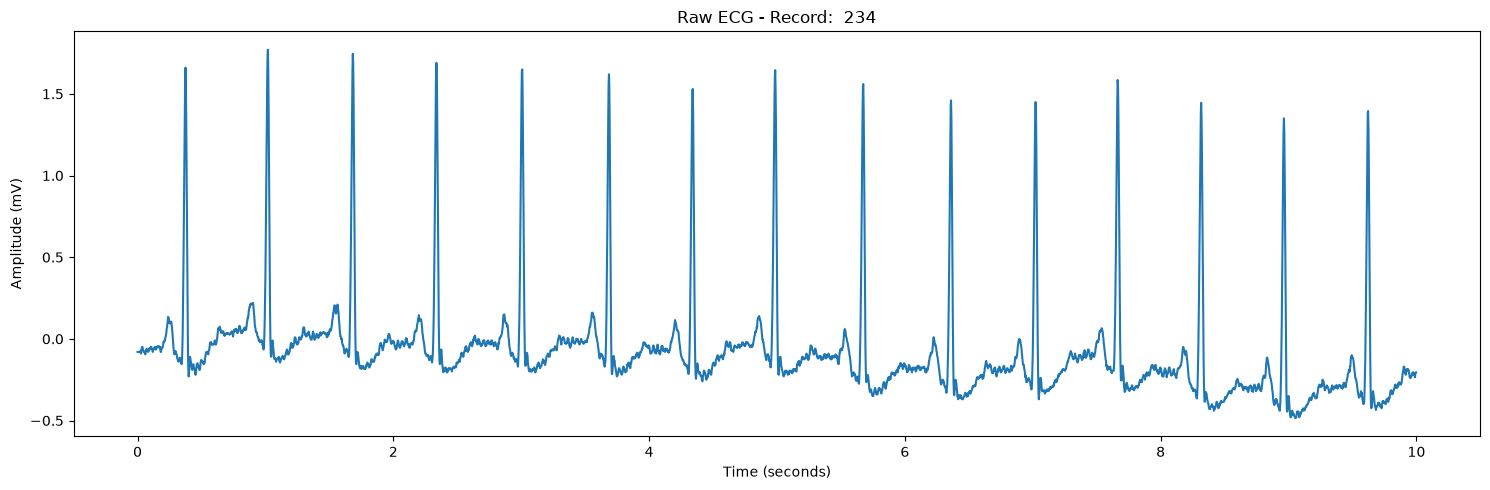

In [104]:
for record_id in records:
    record = wfdb.rdrecord(str(RAW_DIR / record_id))

    signal = record.p_signal[:,0]

    seconds = np.arange(len(signal)) /record.fs

    plt.figure(figsize=(15, 5))
    plt.plot(seconds[:3600], signal[:3600])
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude (mV)")
    plt.title(f"Raw ECG - Record:  {record_id}")
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"raw_ecg_{record_id}.png",
        dpi=300,
        bbox_inches="tight"
    )


Read Anootations

In [105]:
#annotation = wfdb.rdann(str(RAW_DIR / record_id), "atr")
record, annotation = load_record(
    RAW_DIR,
    records[0]
)


In [106]:
print(annotation.sample[:20])
print(annotation.symbol[:20])

[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [107]:
# inspecting the annotation Symbols
from collections import Counter
symbol_counts = Counter(annotation.symbol)
print(symbol_counts)

Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})


In [108]:
annotation_rows = []
for record_id in records:
    annotation = wfdb.rdann(str(RAW_DIR / record_id),"atr")

    counts = Counter(annotation.symbol)

    for symbol, count in counts.items():
        annotation_rows.append({
            "record_id": record_id,
            "symbol": symbol,
            "count": count
        })

        annotation_distribution = pd.DataFrame(annotation_rows)
        annotation_distribution.to_csv(
            METADATA_DIR / "annotation_distribution.csv",
            index=False
        )

In [109]:
annotation_distribution.head()

,record_id,symbol,count
0,100,+,1
1,100,N,2239
2,100,A,33
3,100,V,1
4,101,+,1


In [110]:
len(annotation_distribution)

283

Missing value analysis

In [115]:
#record = wfdb.rdrecord(str(RAW_DIR / record_id))
print(record.__dict__.keys())

dict_keys(['record_name', 'n_sig', 'fs', 'counter_freq', 'base_counter', 'sig_len', 'base_time', 'base_date', 'comments', 'sig_name', 'p_signal', 'd_signal', 'e_p_signal', 'e_d_signal', 'file_name', 'fmt', 'samps_per_frame', 'skew', 'byte_offset', 'adc_gain', 'baseline', 'units', 'adc_res', 'adc_zero', 'init_value', 'checksum', 'block_size'])


In [112]:
signal = record.p_signal
print(f"Number of NaN values: {np.isnan(signal).sum()}")
print(f"Number of Inf values: {np.isinf(signal).sum()}")

Number of NaN values: 0
Number of Inf values: 0


In [114]:
print(f"Signal mean: {np.mean(signal)}")
print(f"Signal std: {np.std(signal)}")  
print(f"Signal min: {np.min(signal)}")
print(f"Signal max: {np.max(signal)}")
print(f"Signal shape: {signal.shape}")

Signal mean: -0.24866670384615383
Signal std: 0.18157117166295547
Signal min: -2.715
Signal max: 1.435
Signal shape: (650000, 2)
